# Motion-Phase ML for Track & Field Athletes: End-to-End Workflow

## Notebook Guide
- **Part 1: Dataset Overview:** quick health checks, class balance, and sensor visualizations.
- **Part 2: Preprocessing:** duplicate removal, timestamp cleanup, sampling-rate diagnostics, and segmentation.
- **Part 3: Feature Engineering:** engineered statistics and spectral features, feature ranking, and artifact generation for modeling.
- **Part 4: Model Training and Hyperparameter Tuning:** model selection, pipeline setup, cross-validation, GridSearchCV tuning, and saving trained models.
- **Part 5:Evaluation:**

## Setup and Configuration

This section imports all required libraries and defines global settings used throughout the notebook. It covers:
- Data handling and plotting libraries for analysis and diagnostics.
- Signal processing and feature-selection tools .
- Reproducible output paths and constants.

In [11]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.fft import rfft, rfftfreq
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif, f_classif
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder

plt.style.use("seaborn-v0_8")
sns.set_palette("crest")


In [12]:
DATA_PATH = Path("data/biosensor_dataset_with_target.csv")
print(f"Using dataset at: {DATA_PATH.resolve()}")

Using dataset at: /content/data/biosensor_dataset_with_target.csv


### Runtime Output Paths & Parameters

In [13]:
# root
OUT_DIR = Path("out")

# section dirs
S1 = OUT_DIR / "01_dataset_exploration"
S2 = OUT_DIR / "02_signal_exploration"
S3 = OUT_DIR / "03_preprocessing"
S4 = OUT_DIR / "04_windowing"
S5 = OUT_DIR / "05_features"
S6 = OUT_DIR / "06_modeling"
S7 = OUT_DIR / "07_evaluation"

# leaf dirs
PATHS = [
    S1 / "tables", S1 / "plots",
    S2 / "plots",
    S3 / "plots",
    S4 / "tables", S4 / "plots",
    S5 / "tables", S5 / "plots",
    S6 / "tables", S6 / "plots",
    S7 / "tables", S7 / "plots",
    OUT_DIR / "report" / "figures",
]

for p in PATHS:
    p.mkdir(parents=True, exist_ok=True)

print(f"Artifacts will be saved under {OUT_DIR.resolve()}")

Artifacts will be saved under /content/out


In [14]:
RAW_SENSOR_COLS = [
    "Heart_Rate", "Acc_X", "Acc_Y", "Acc_Z",
    "Gyro_X", "Gyro_Y", "Gyro_Z",
]
FEATURE_COLS = RAW_SENSOR_COLS  # 7 channels: Heart_Rate + Acc_X/Y/Z + Gyro_X/Y/Z

SENSOR_THRESHOLDS = {
    "Heart_Rate": (60.0, 190.0),
    "Acc_X": (-3.2, 3.2), "Acc_Y": (-3.2, 3.2), "Acc_Z": (-3.2, 3.2),
    "Gyro_X": (-190.0, 190.0), "Gyro_Y": (-190.0, 190.0), "Gyro_Z": (-190.0, 190.0),
}

WINDOW_SECONDS = 1.0    # seconds — selected from sweep
FS             = 10.0    # Hz — confirmed from sampling rate analysis
STEP_RATIO     = 0.25
STEP_SECONDS   = WINDOW_SECONDS * STEP_RATIO
TOP_N          = 20
RANDOM_STATE   = 42

# Shared CV helpers, used by all model/sweep cells
le = LabelEncoder()

def make_rf():
    return RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)

def run_rf_cv(X, y_enc, n_splits=5):
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    return cross_val_score(make_rf(), X, y_enc, cv=cv, scoring="f1_macro")

def safe_n_splits(y_enc, max_splits=5):
    return min(max_splits, np.bincount(y_enc).min())


## PART 1: DATASET OVERVIEW PORTION

### Read Raw Data from File

This cell loads the biosensor CSV into a dataframe and converts `Timestamp` into a proper datetime column.

It gives a first check that:
- the file path is correct,
- the number of rows and columns
- number of athletes and days per athlete
- demographic diversity check  


The printed summary and preview help confirm the raw file was read correctly.

In [15]:

df_raw = pd.read_csv(DATA_PATH)
df_raw["Timestamp"] = pd.to_datetime(df_raw["Timestamp"], errors="coerce")
print(f"Reading from {DATA_PATH}")
print(f"Rows: {len(df_raw):,}  |  Columns: {len(df_raw.columns)}")

Reading from data/biosensor_dataset_with_target.csv
Rows: 1,500  |  Columns: 10


In [16]:
n_athletes = df_raw["Athlete_ID"].nunique()
total_records = len(df_raw)
records_per_athlete_avg = total_records // n_athletes
sensor_channels = len(RAW_SENSOR_COLS)
n_classes = df_raw["Event_Label"].nunique()

# Data span per athlete
span_per_athlete = df_raw.groupby("Athlete_ID")["Timestamp"].apply(
    lambda t: (t.max() - t.min()).total_seconds()
)
avg_span_s = round(span_per_athlete.mean(), 1)

summary = pd.DataFrame({
    "Property": [
        "Number of athletes",
        "Total records",
        "Records per athlete (avg)",
        "Sensor channels",
        "Motion phase classes",
        "Data span per athlete (avg)",
        "Demographic info",
    ],
    "Value": [
        n_athletes,
        f"{total_records:,}",
        records_per_athlete_avg,
        sensor_channels,
        n_classes,
        f"{avg_span_s} s",
        "Not provided",
    ],
}).set_index("Property")

display(summary)
summary.to_csv(S1 / "tables" / "dataset_summary.csv")


,Value
Property,
Number of athletes,5
Total records,"1,500"
Records per athlete (avg),300
Sensor channels,7
Motion phase classes,6
Data span per athlete (avg),29.9 s
Demographic info,Not provided


### Target Class Balance Snapshot

Computes counts and percentages for each motion phase label

,count,percent
Event_Label,,
Start_Run,281,18.73
Stop,257,17.13
Jump_Takeoff,246,16.40
Sprint_Mid,245,16.33
Accel,241,16.07
Landing,230,15.33


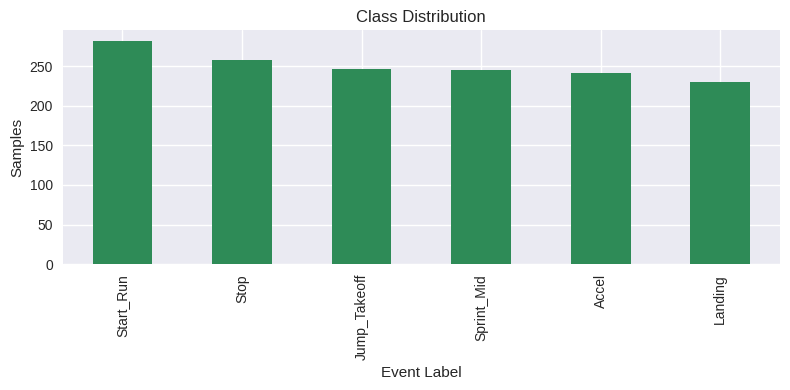

In [17]:
# class distribution
class_counts = df_raw['Event_Label'].value_counts()
class_dist = pd.DataFrame({"count": class_counts, "percent": (class_counts / len(df_raw) * 100).round(2)})
display(class_dist)
class_dist.to_csv(S1 / "tables" / "class_distribution.csv")

ax = class_counts.plot(kind="bar", color="seagreen", figsize=(8, 4))
ax.set(title="Class Distribution", xlabel="Event Label", ylabel="Samples")
plt.tight_layout()
plt.savefig(S1 / "plots" / "class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close('all')


### Check for Missing Values

Summarizes missing values per column and reports total missing entries across all sensor channels.

In [18]:
missing_counts = df_raw.isna().sum()
missing_summary = pd.DataFrame({"missing": missing_counts})
display(missing_summary)
missing_summary.to_csv(S1 / "tables" / "missing_values.csv")

total_missing = missing_counts.sum()
if total_missing == 0:
    print("No missing values detected across any channel.")
else:
    print(f"Total missing entries: {total_missing}")
    print("Channels with gaps:", missing_counts[missing_counts > 0].index.tolist())


,missing
Heart_Rate,0
Acc_X,0
Acc_Y,0
Acc_Z,0
Gyro_X,0
Gyro_Y,0
Gyro_Z,0
Event_Label,0
Timestamp,0
Athlete_ID,0


No missing values detected across any channel.


### Compute Derived Magnitude Signals

Calculate the Euclidean magnitude of 3-axis accelerometer and gyroscope readings.
These provide a single measure of overall intensity without axis decomposition.


In [19]:
df_raw["Acc_Mag"] = np.sqrt(df_raw["Acc_X"]**2 + df_raw["Acc_Y"]**2 + df_raw["Acc_Z"]**2)
df_raw["Gyro_Mag"] = np.sqrt(df_raw["Gyro_X"]**2 + df_raw["Gyro_Y"]**2 + df_raw["Gyro_Z"]**2)
print("✓ Computed Acc_Mag and Gyro_Mag")

✓ Computed Acc_Mag and Gyro_Mag


### PER CLASS SUMMARY STATS

In [20]:
# Per-class summary statistics
sensor_cols = ["Heart_Rate", "Acc_Mag", "Gyro_Mag"]
summary_stats = df_raw.groupby('Event_Label')[sensor_cols].agg(['mean', 'std']).round(2)
display(summary_stats)

Heart_Rate        Acc_Mag       Gyro_Mag       
                   mean    std    mean   std     mean    std
Event_Label                                                 
Accel            129.05  30.12    2.91  0.81   172.91  45.24
Jump_Takeoff     130.89  27.53    2.88  0.87   174.73  49.90
Landing          128.97  29.54    2.85  0.81   175.40  48.55
Sprint_Mid       128.84  28.28    2.90  0.81   172.19  48.18
Start_Run        127.38  29.50    2.86  0.78   178.58  51.31
Stop             128.74  29.79    2.94  0.79   174.16  49.43

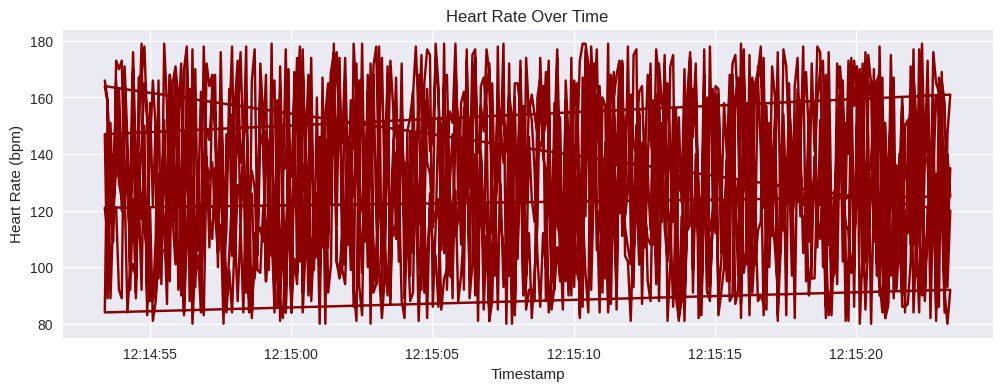

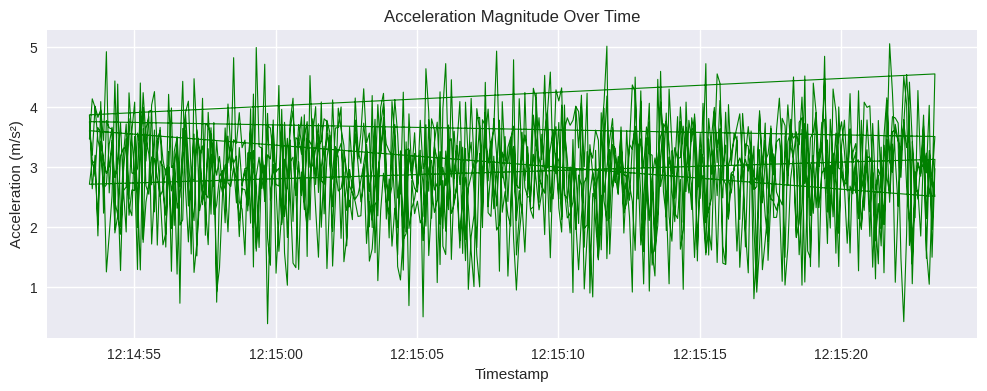

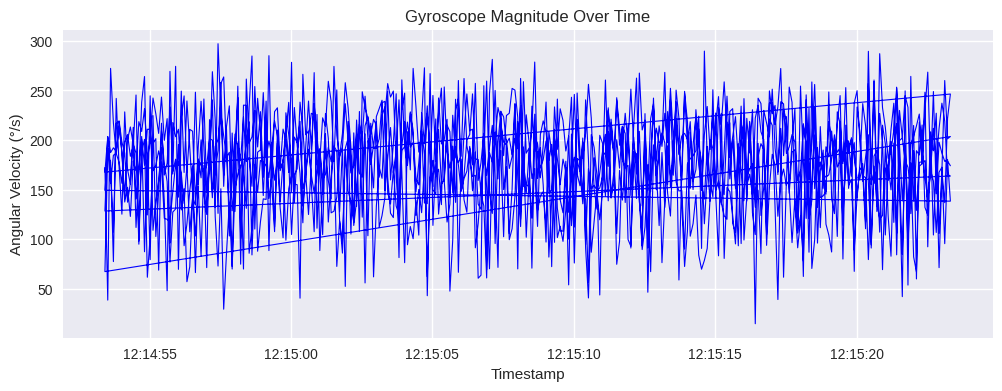

In [21]:
# heart rate over time
plt.figure(figsize=(12, 4))
plt.plot(df_raw['Timestamp'], df_raw['Heart_Rate'], color='darkred')
plt.title('Heart Rate Over Time')
plt.xlabel('Timestamp')
plt.ylabel('Heart Rate (bpm)')
plt.show()

# accelerometer magnitude over time
plt.figure(figsize=(12, 4))
plt.plot(df_raw['Timestamp'], df_raw['Acc_Mag'], color='green', linewidth=0.8)
plt.title('Acceleration Magnitude Over Time')
plt.xlabel('Timestamp')
plt.ylabel('Acceleration (m/s²)')
plt.show()

# gyroscope magnitude over time
plt.figure(figsize=(12, 4))
plt.plot(df_raw['Timestamp'], df_raw['Gyro_Mag'], color='blue', linewidth=0.8)
plt.title('Gyroscope Magnitude Over Time')
plt.xlabel('Timestamp')
plt.ylabel('Angular Velocity (°/s)')
plt.show()



# ANNOTATED SIGNAL EXPLORATION

### Sensor Distributions by Event Label

Boxplots of Heart Rate, Acceleration Magnitude, and Gyroscope Magnitude grouped by motion phase.
Overlapping distributions suggest phases are harder to discriminate; separated distributions indicate the sensors are informative for classification.

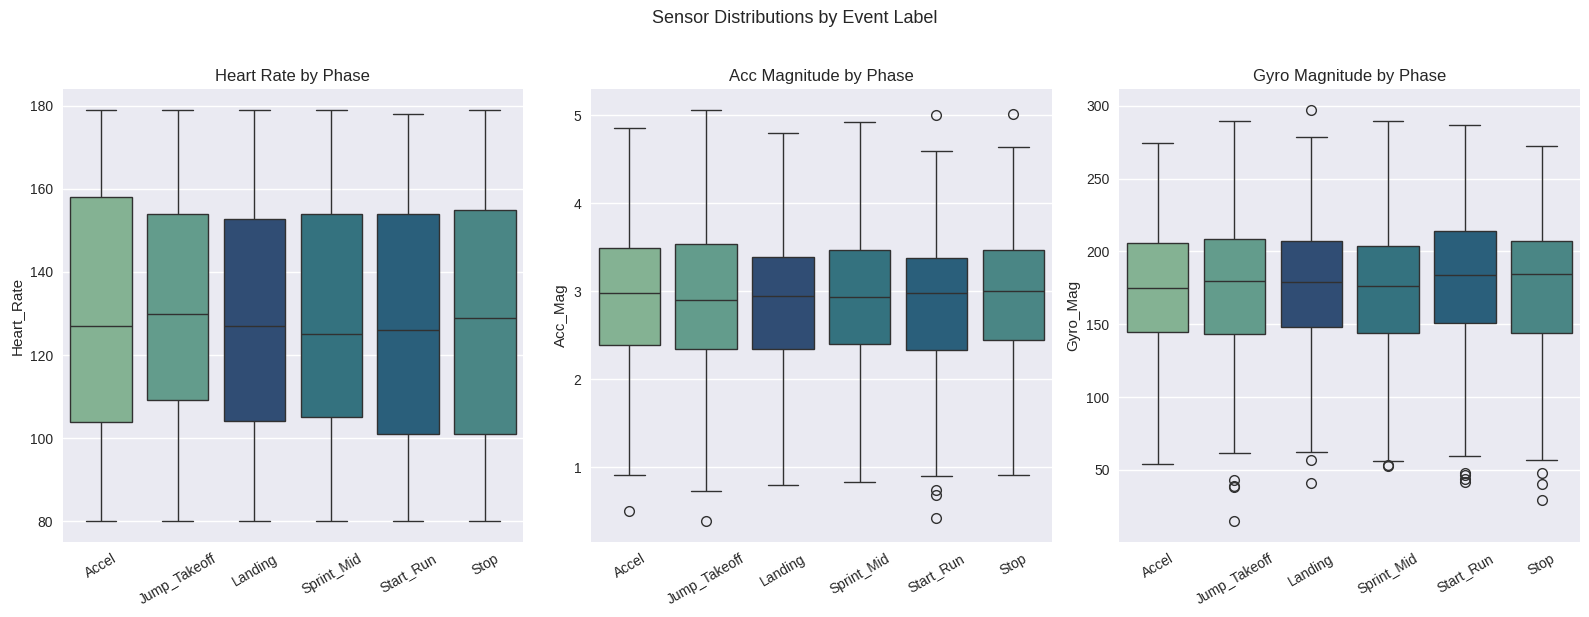

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

order = sorted(df_raw['Event_Label'].unique())

sns.boxplot(data=df_raw, x='Event_Label', y='Heart_Rate', order=order, hue='Event_Label', legend=False, ax=axes[0], palette='crest')
axes[0].set_title('Heart Rate by Phase')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)

sns.boxplot(data=df_raw, x='Event_Label', y='Acc_Mag', order=order, hue='Event_Label', legend=False, ax=axes[1], palette='crest')
axes[1].set_title('Acc Magnitude by Phase')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)

sns.boxplot(data=df_raw, x='Event_Label', y='Gyro_Mag', order=order, hue='Event_Label', legend=False, ax=axes[2], palette='crest')
axes[2].set_title('Gyro Magnitude by Phase')
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=30)

plt.suptitle('Sensor Distributions by Event Label', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(S1 / 'plots' / 'sensor_distributions_by_label.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close('all')


### Annotated Signal Exploration

For each of the 6 motion phase labels, a representative 51-sample window (25 before, 25 after) is extracted from Athlete A001 and plotted across three derived signals: Heart Rate, Acceleration Magnitude, and Gyroscope Magnitude. A vertical dashed line marks the event onset boundary.

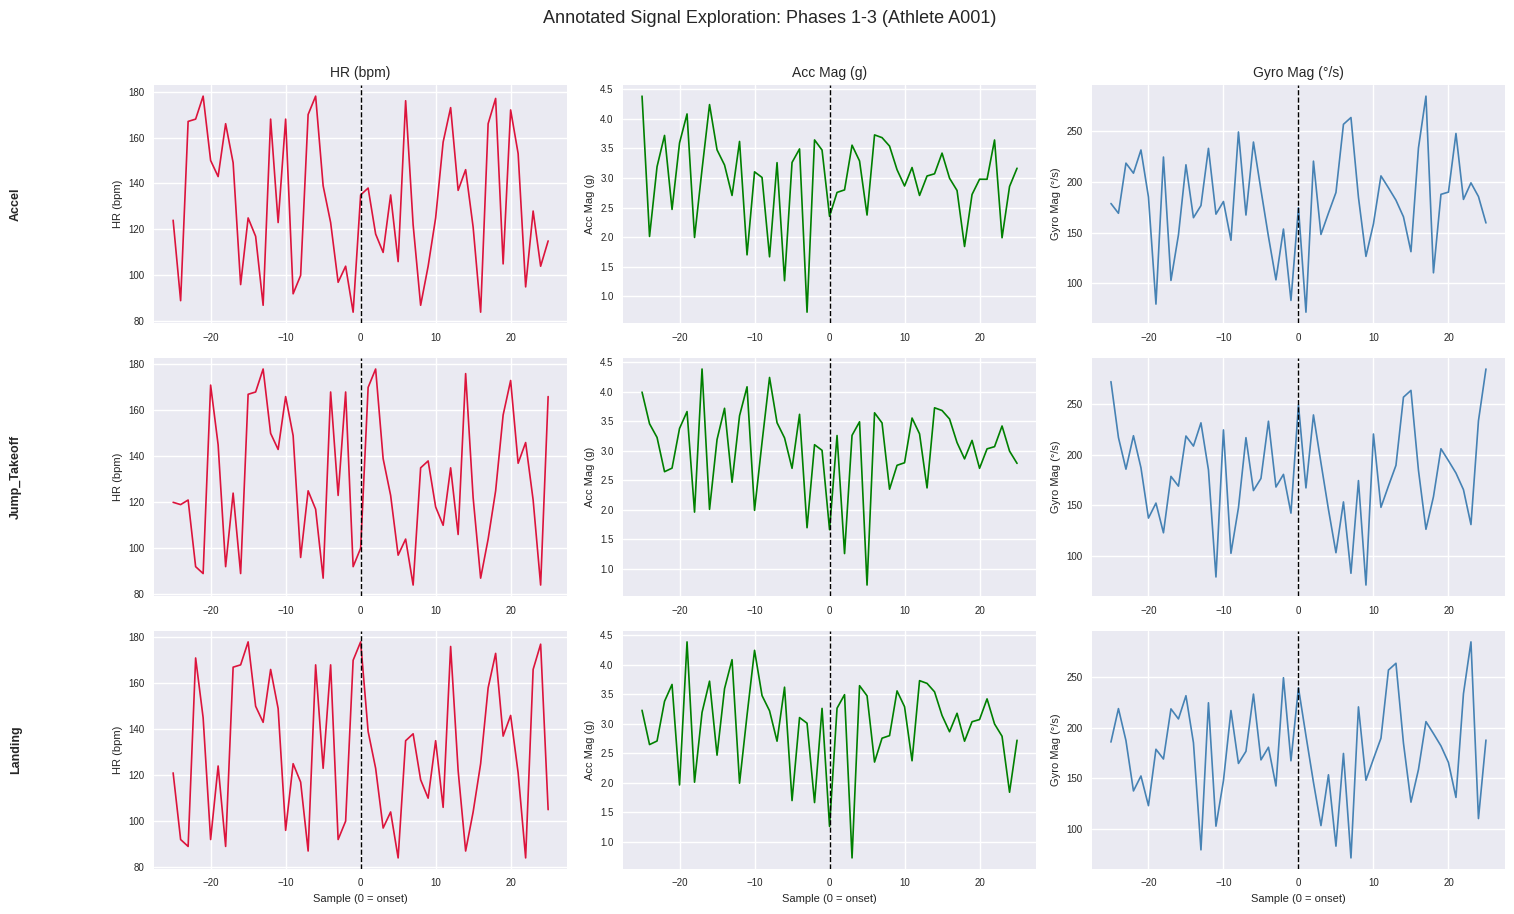

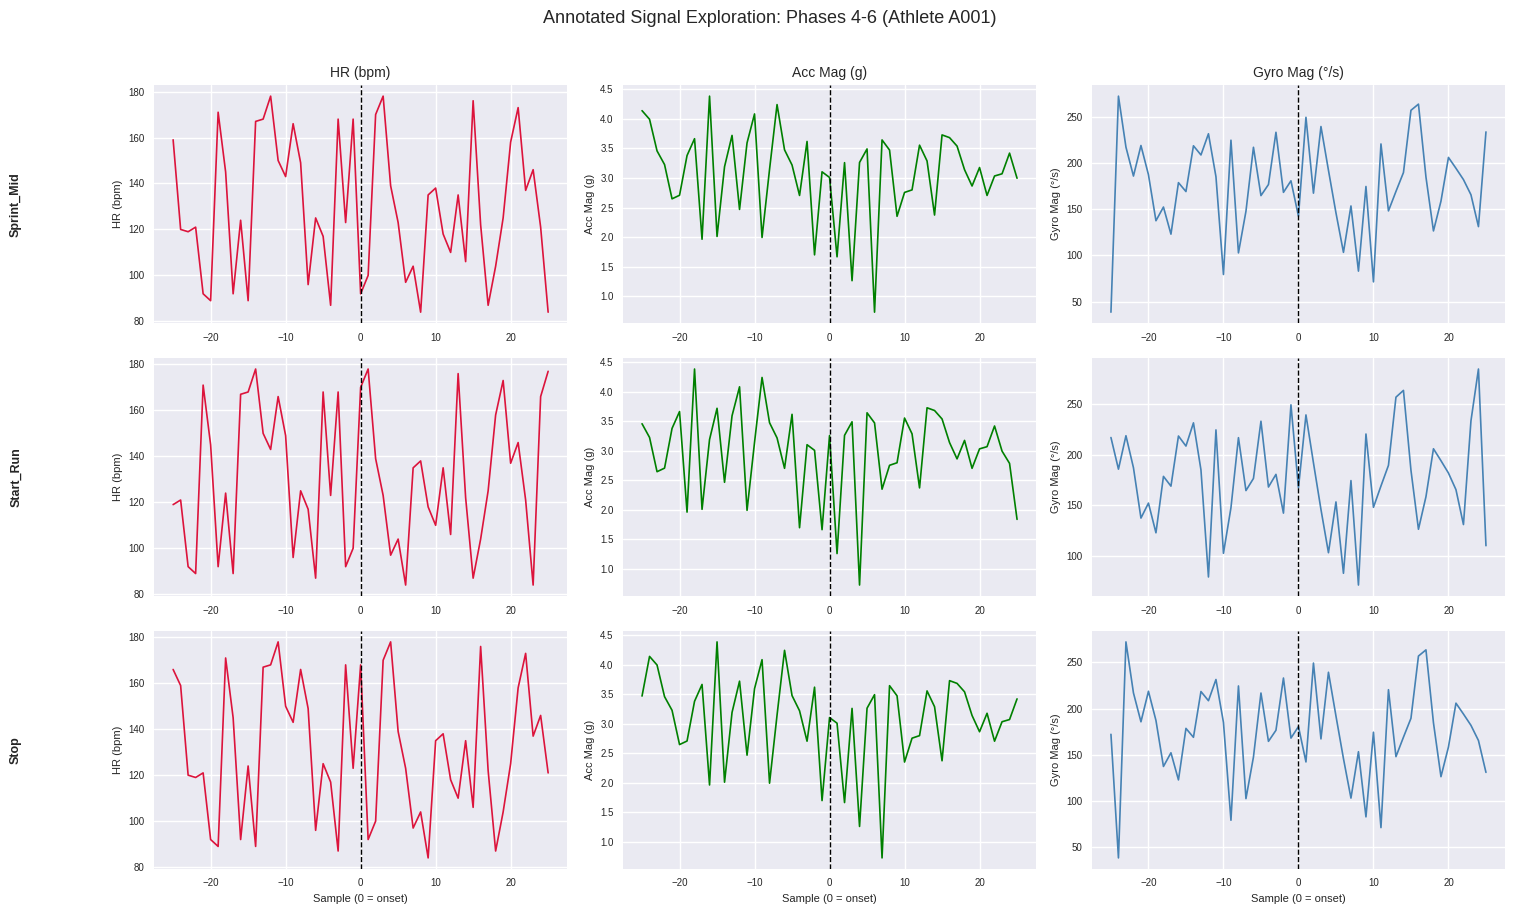


Signal Pattern Analysis:
- Heart Rate: Broadly similar across phases due to synthetic data generation. The average HR per athlete plot reveals individual differences.
- Accelerometer: Magnitude captures overall movement intensity. Box plots show overlapping distributions across phases,motivating the need for feature engineering.
- Gyroscope: Angular velocity is similarly distributed across phases, suggesting rotational patterns require spectral features to differentiate motion classes.
- Annotated event plots show the raw signal context around each labeled motion phase for a single representative athlete.



In [23]:
WINDOW  = 25
LABELS  = sorted(df_raw["Event_Label"].unique())
SIGNALS = ["Heart_Rate", "Acc_Mag", "Gyro_Mag"]
COLORS  = {"Heart_Rate": "crimson", "Acc_Mag": "green", "Gyro_Mag": "steelblue"}
YLABELS = {"Heart_Rate": "HR (bpm)", "Acc_Mag": "Acc Mag (g)", "Gyro_Mag": "Gyro Mag (°/s)"}

athlete = df_raw[df_raw["Athlete_ID"] == "A001"].sort_values("Timestamp").reset_index(drop=True)

def plot_signal_grid(labels, title, filename):
    fig, axes = plt.subplots(3, 3, figsize=(15, 9))

    for row, label in enumerate(labels):
        onsets = athlete[
            (athlete["Event_Label"] == label) &
            (athlete["Event_Label"].shift(1) != label)
        ].index
        valid = [i for i in onsets if i >= WINDOW and i + WINDOW < len(athlete)]

        if not valid:
            for col in range(3):
                axes[row, col].text(0.5, 0.5, "No valid window", ha="center", va="center",
                                    transform=axes[row, col].transAxes)
            continue

        transition_idx = valid[0]
        segment = athlete.iloc[transition_idx - WINDOW: transition_idx + WINDOW + 1].copy()
        segment["sample"] = range(-WINDOW, WINDOW + 1)

        for col, signal in enumerate(SIGNALS):
            ax = axes[row, col]
            ax.plot(segment["sample"], segment[signal], color=COLORS[signal], linewidth=1.2)
            ax.axvline(0, color="black", linestyle="--", linewidth=1.0)
            ax.set_ylabel(YLABELS[signal], fontsize=8)
            ax.tick_params(labelsize=7)

            if row == 0:
                ax.set_title(YLABELS[signal], fontsize=10)
            if row == 2:
                ax.set_xlabel("Sample (0 = onset)", fontsize=8)

        axes[row, 0].annotate(
            label, xy=(-0.35, 0.5), xycoords="axes fraction",
            fontsize=9, fontweight="bold", va="center", ha="left", rotation=90
        )

    plt.suptitle(title, fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig(S2 / "plots" / filename, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close("all")

plot_signal_grid(
    LABELS[:3],
    "Annotated Signal Exploration: Phases 1-3 (Athlete A001)",
    "annotated_signal_exploration_1.png"
)

plot_signal_grid(
    LABELS[3:],
    "Annotated Signal Exploration: Phases 4-6 (Athlete A001)",
    "annotated_signal_exploration_2.png"
)

print("""
Signal Pattern Analysis:
- Heart Rate: Broadly similar across phases due to synthetic data generation. The average HR per athlete plot reveals individual differences.
- Accelerometer: Magnitude captures overall movement intensity. Box plots show overlapping distributions across phases,motivating the need for feature engineering.
- Gyroscope: Angular velocity is similarly distributed across phases, suggesting rotational patterns require spectral features to differentiate motion classes.
- Annotated event plots show the raw signal context around each labeled motion phase for a single representative athlete.
""")


## PART 2: DATASET PREPROCESSING

### Clean Records and Normalize Labels
- No missing values confirmed.
- Removes duplicate rows.
- Drops invalid timestamps.
- Sorts by athlete and time.
- Normalizes `Event_Label` text for consistent grouping and modeling.

In [24]:
df_clean = df_raw.copy()

rows_before = len(df_clean)
df_clean = df_clean.drop_duplicates(keep="first")
print(f"Removed {rows_before - len(df_clean)} duplicate rows")

invalid_ts = int(df_clean["Timestamp"].isna().sum())
if invalid_ts:
    print(f"Dropping {invalid_ts} rows with invalid timestamps")
    df_clean = df_clean.dropna(subset=["Timestamp"])

df_clean = df_clean.sort_values(["Athlete_ID", "Timestamp"])

# Reset index once
df_clean = df_clean.reset_index(drop=True)

df_clean["Event_Label"] = (
    df_clean["Event_Label"].astype(str).str.strip().str.lower()
)

Removed 0 duplicate rows


#### Missing Value Findings & Interpolation Strategy

**Findings:** No missing values were detected across any of the 7 sensor channels (`Heart_Rate`, `Acc_X`, `Acc_Y`, `Acc_Z`, `Gyro_X`, `Gyro_Y`, `Gyro_Z`), the event label column, or the timestamp column. The dataset is complete as received.

**Interpolation strategy (if gaps were present):**

| Channel | Strategy | Rationale |
|---|---|---|
| `Heart_Rate` | Linear interpolation | HR changes slowly and smoothly; linear fill preserves physiological trend between adjacent readings |
| `Acc_X/Y/Z` | Linear interpolation | Short gaps in accelerometer data are well approximated by linear transitions between samples at 10 Hz |
| `Gyro_X/Y/Z` | Linear interpolation | Same reasoning as accelerometer; gyroscope signals are continuous and slowly varying within a phase |

For all channels, interpolation would be applied within each athlete's session separately to avoid bleeding values across athletes. Gaps longer than **5 consecutive samples (0.5 s at 10 Hz)** would be flagged rather than interpolated, as large gaps indicate sensor dropout rather than noise and could corrupt window-level features downstream.

### Sensor Range Checks

Compares observed numeric ranges with expected physiological and sensor limits.

In [25]:
numeric_cols = df_clean.select_dtypes(include="number").columns
range_rows = []
for col in numeric_cols:
    range_rows.append({
        "column": col,
       "min": round(df_clean[col].min(), 2),
        "max": round(df_clean[col].max(), 2),
    })
range_df = pd.DataFrame(range_rows).set_index("column").T


LOW_Q = 0.01
HIGH_Q = 0.99
BUFFER = 0.1

SENSOR_THRESHOLDS = {}

for col in numeric_cols:
    low = df_clean[col].quantile(LOW_Q)
    high = df_clean[col].quantile(HIGH_Q)
    span = high - low

    SENSOR_THRESHOLDS[col] = (
        low - BUFFER * span,
        high + BUFFER * span,
    )

display(range_df)

threshold_counts = {}
for col, (low, high) in SENSOR_THRESHOLDS.items():
    if col in df_clean.columns:
        count = int(((df_clean[col] < low) | (df_clean[col] > high)).sum())
        threshold_counts[col] = count

display(pd.Series(threshold_counts, name="out_of_range"))
print("Only a negligible number of outliers (<0.1%) were detected using percentile-based thresholds.")
print("So, no outlier filtering was applied.")

column,Heart_Rate,Acc_X,Acc_Y,Acc_Z,Gyro_X,Gyro_Y,Gyro_Z,Acc_Mag,Gyro_Mag
min,80.0,-3.0,-2.99,-3.0,-179.94,-180.0,-179.89,0.39,14.69
max,179.0,3.0,3.00,3.0,179.89,179.8,179.88,5.06,297.10


,out_of_range
Heart_Rate,0
Acc_X,0
Acc_Y,0
Acc_Z,0
Gyro_X,0
Gyro_Y,0
Gyro_Z,0
Acc_Mag,8
Gyro_Mag,3


Only a negligible number of outliers (<0.1%) were detected using percentile-based thresholds.
So, no outlier filtering was applied.


### Sampling Rate Estimation

Computes the inter-sample interval per athlete from the timestamps to confirm the effective sampling rate before any preprocessing decisions.

In [26]:
# Compute inter-sample intervals per athlete
intervals = (
    df_clean.groupby("Athlete_ID")["Timestamp"]
    .apply(lambda t: t.sort_values().diff().dt.total_seconds().dropna())
)

interval_stats = intervals.groupby(level=0).agg(
    mean_interval=("mean"),
    median_interval=("median"),
    std_interval=("std"),
    min_interval=("min"),
    max_interval=("max"),
)
interval_stats["sampling_rate_hz"] = (1 / interval_stats["median_interval"]).round(2)

display(interval_stats.round(4))
interval_stats.to_csv(S3 / "plots" / "sampling_rate_per_athlete.csv")

overall_median = intervals.median()
overall_hz = round(1 / overall_median, 2)
print(f"\nOverall median inter-sample interval : {overall_median:.4f} s")
print(f"Overall effective sampling rate       : {overall_hz} Hz")


,mean_interval,median_interval,std_interval,min_interval,max_interval,sampling_rate_hz
Athlete_ID,,,,,,
A001,0.1,0.1,0.0,0.1,0.1,10.0
A002,0.1,0.1,0.0,0.1,0.1,10.0
A003,0.1,0.1,0.0,0.1,0.1,10.0
A004,0.1,0.1,0.0,0.1,0.1,10.0
A005,0.1,0.1,0.0,0.1,0.1,10.0



Overall median inter-sample interval : 0.1000 s
Overall effective sampling rate       : 10.0 Hz


### Signal Preprocessing: Filtering Decision

The dataset was sampled at 10 Hz, giving a Nyquist frequency of 5 Hz. Because the target movements include rapid transitions such as sprint initiation and jump landing, applying a low-pass filter could attenuate short-duration peaks and smooth motion-relevant transients.


Application of a low-pass Butterworth filter to the 10Hz signals produced no meaningful noise reduction and in some channels introduced signal distortion, widening the amplitude range beyond the raw signal. This confirms that filtering is inappropriate for this sampling rate and the preprocessing pipeline proceeds without it.


In [27]:
print("No filtering applied, raw signal values retained for all channels.")

No filtering applied, raw signal values retained for all channels.


### Per Athlete Z score normalization

Each athlete has their own baseline physiology and movement style. Per-athlete z-score means: for each athlete separately, subtract their own mean and divide by their own std for each channel. So every athlete's signals are centered at 0 with unit variance, the model then sees motion shape, not athlete baseline.

This matters most for LOEO, when you train on 4 athletes and test on the 5th, if the test athlete's scale is different from the training athletes, the model struggles. Normalizing per athlete removes that problem.

Post-normalization check (mean ≈ 0, std ≈ 1 per athlete):


Heart_Rate      Acc_X      Acc_Y      Acc_Z      Gyro_X       \
                 mean  std  mean  std  mean  std  mean  std   mean  std   
Athlete_ID                                                                
A001             -0.0  1.0   0.0  1.0  -0.0  1.0  -0.0  1.0    0.0  1.0   
A002             -0.0  1.0  -0.0  1.0   0.0  1.0  -0.0  1.0    0.0  1.0   
A003             -0.0  1.0  -0.0  1.0  -0.0  1.0  -0.0  1.0    0.0  1.0   
A004             -0.0  1.0  -0.0  1.0   0.0  1.0  -0.0  1.0   -0.0  1.0   
A005             -0.0  1.0  -0.0  1.0  -0.0  1.0  -0.0  1.0    0.0  1.0   

           Gyro_Y      Gyro_Z      Acc_Mag      Gyro_Mag       
             mean  std   mean  std    mean  std     mean  std  
Athlete_ID                                                     
A001          0.0  1.0   -0.0  1.0     0.0  1.0     -0.0  1.0  
A002         -0.0  1.0   -0.0  1.0     0.0  1.0     -0.0  1.0  
A003          0.0  1.0   -0.0  1.0    -0.0  1.0      0.0  1.0  
A004          0.0  1.0    0.0  1.0     0.0  1.0      0.0  1.0  
A005         -0.0  1.0   -0.0  1.0     0.0  1.0     -0.0  1.0

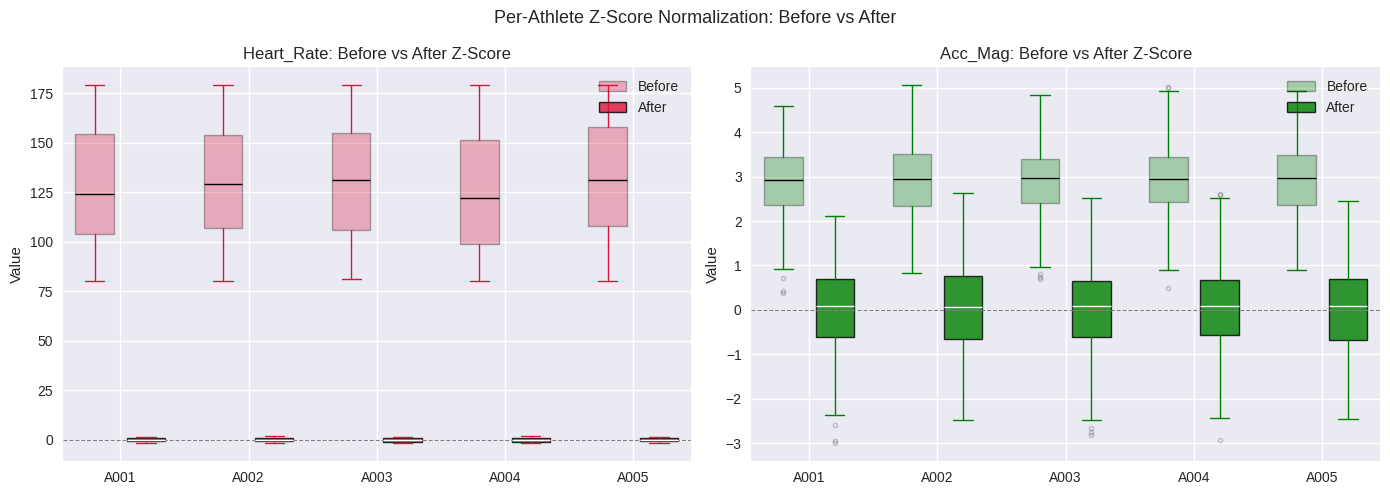

In [28]:
NORM_COLS = ["Heart_Rate", "Acc_X", "Acc_Y", "Acc_Z", "Gyro_X", "Gyro_Y", "Gyro_Z", "Acc_Mag", "Gyro_Mag"]

# Snapshot before normalization for plotting
df_before = df_clean[["Athlete_ID", "Heart_Rate", "Acc_Mag"]].copy()
df_before["stage"] = "Before"

# Per-athlete z-score normalization
for col in NORM_COLS:
    df_clean[col] = df_clean.groupby("Athlete_ID")[col].transform(
        lambda x: (x - x.mean()) / x.std()
    )

# Snapshot after normalization
df_after = df_clean[["Athlete_ID", "Heart_Rate", "Acc_Mag"]].copy()
df_after["stage"] = "After"

# Verify: mean ≈ 0 and std ≈ 1 per athlete
verification = df_clean.groupby("Athlete_ID")[NORM_COLS].agg(["mean", "std"]).round(4)
print("Post-normalization check (mean ≈ 0, std ≈ 1 per athlete):")
display(verification)

# Before / after plot
df_compare = pd.concat([df_before, df_after], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, color in zip(axes, ["Heart_Rate", "Acc_Mag"], ["crimson", "green"]):
    before = df_compare[df_compare["stage"] == "Before"]
    after  = df_compare[df_compare["stage"] == "After"]

    positions_before = [i * 2     for i in range(5)]
    positions_after  = [i * 2 + 0.8 for i in range(5)]
    athletes = sorted(df_clean["Athlete_ID"].unique())

    bp1 = ax.boxplot(
        [before[before["Athlete_ID"] == a][col].values for a in athletes],
        positions=positions_before, widths=0.6, patch_artist=True,
        boxprops=dict(facecolor=color, alpha=0.3),
        medianprops=dict(color="black"), whiskerprops=dict(color=color),
        capprops=dict(color=color), flierprops=dict(marker=".", color=color, alpha=0.2)
    )
    bp2 = ax.boxplot(
        [after[after["Athlete_ID"] == a][col].values for a in athletes],
        positions=positions_after, widths=0.6, patch_artist=True,
        boxprops=dict(facecolor=color, alpha=0.8),
        medianprops=dict(color="white"), whiskerprops=dict(color=color),
        capprops=dict(color=color), flierprops=dict(marker=".", color=color, alpha=0.2)
    )

    ax.set_xticks([i * 2 + 0.4 for i in range(5)])
    ax.set_xticklabels(athletes)
    ax.set_title(f"{col}: Before vs After Z-Score")
    ax.set_ylabel("Value")
    ax.axhline(0, color="grey", linestyle="--", linewidth=0.8)
    ax.legend([bp1["boxes"][0], bp2["boxes"][0]], ["Before", "After"], loc="upper right")

plt.suptitle("Per-Athlete Z-Score Normalization: Before vs After", fontsize=13)
plt.tight_layout()
plt.savefig(S3 / "plots" / "zscore_normalization_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close("all")


> Note: Per-athlete z-score normalization was applied to all channels. While inter-athlete baseline differences were minimal in this dataset, as evidenced by the similar pre-normalization distributions across athletes, normalization is retained as a standard preprocessing step to ensure scale invariance during LOEO evaluation, where the test athlete's signal range must be comparable to training athletes.

## Segmentation Strategy

A sliding window sweep was conducted across 10 window sizes (0.5 s to 5.0 s at 10 Hz) using majority-label assignment and stratified k-fold cross-validation. Analysis of the dataset's event block structure revealed a median consecutive block length of 1 row (0.1 s) and a maximum of 6 rows (0.6 s).

Sliding window analysis showed W=1.0 s as the optimal size and yielding the most stable cross-validation performance. This window size is carried forward for feature extraction.

### Sliding Window Sweep (Evidence)

F1-macro was measured for 10 window sizes (0.5 s–5.0 s) using majority-label assignment to establish whether any window size produces stable classification.

,window_s,n_windows,f1_mean,f1_std
0,0.5,1180,0.4700,0.0153
1,1.0,580,0.4669,0.0757
2,1.5,380,0.4841,0.0277
3,2.0,280,0.4976,0.0760
4,2.5,220,0.5151,0.0975
5,3.0,180,0.4700,0.0909
6,3.5,155,0.3532,0.0738
7,4.0,130,0.5193,0.1092
8,4.5,115,0.4867,0.0536
9,5.0,100,0.5552,0.1022


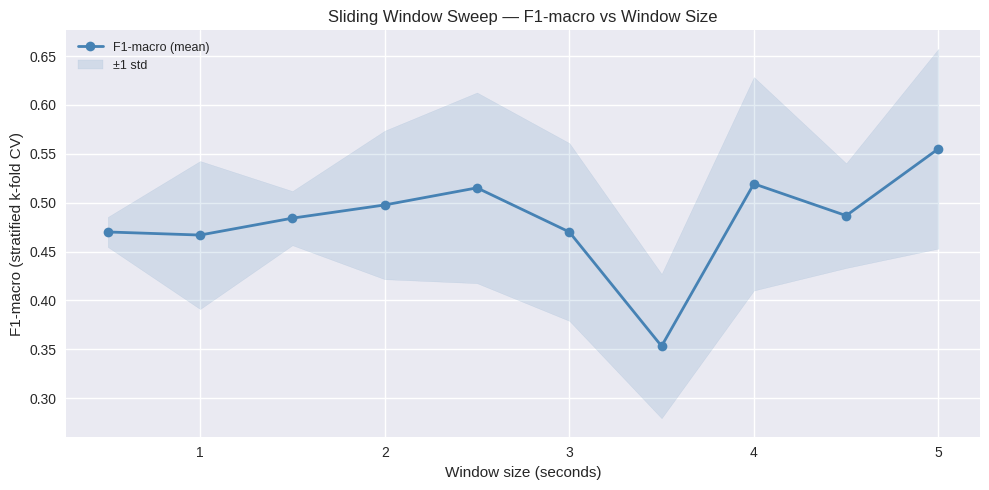

In [29]:
WINDOW_SIZES_SW = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]  # seconds, 10 uniform steps

def extract_sliding_windows(df, window_seconds, step_ratio=STEP_RATIO):
    window_delta = pd.to_timedelta(window_seconds, unit="s")
    step_delta   = pd.to_timedelta(window_seconds * step_ratio, unit="s")
    X, y = [], []
    for _, group in df.groupby("Athlete_ID"):
        group        = group.sort_values("Timestamp")
        current_time = group["Timestamp"].min()
        end_time     = group["Timestamp"].max()
        while current_time + window_delta <= end_time:
            win = group[
                (group["Timestamp"] >= current_time) &
                (group["Timestamp"] <  current_time + window_delta)
            ]
            if len(win) > 0:
                data         = win[FEATURE_COLS].values
                chunk_labels = win["Event_Label"].values
                unique, counts = np.unique(chunk_labels, return_counts=True)
                majority = unique[np.argmax(counts)]
                feats = np.concatenate([data.mean(axis=0), data.std(axis=0),
                                        data.min(axis=0),  data.max(axis=0)])
                X.append(feats)
                y.append(majority)
            current_time += step_delta
    return np.array(X), np.array(y)

sw_results = []

for ws in WINDOW_SIZES_SW:
    X, y = extract_sliding_windows(df_clean, ws)
    if len(X) == 0:
        continue
    y_enc    = le.fit_transform(y)
    n_splits = safe_n_splits(y_enc)
    if n_splits < 2:
        continue
    f1 = run_rf_cv(X, y_enc, n_splits)
    sw_results.append({"window_s": ws, "n_windows": len(X),
                       "f1_mean": f1.mean(), "f1_std": f1.std()})

sw_df = pd.DataFrame(sw_results)
display(sw_df.round(4))
sw_df.to_csv(S4 / "tables" / "sliding_window_sweep.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(sw_df["window_s"], sw_df["f1_mean"], marker="o", color="steelblue", linewidth=2, label="F1-macro (mean)")
ax.fill_between(sw_df["window_s"],
                sw_df["f1_mean"] - sw_df["f1_std"],
                sw_df["f1_mean"] + sw_df["f1_std"],
                alpha=0.15, color="steelblue", label="±1 std")
ax.set_xlabel("Window size (seconds)", fontsize=11)
ax.set_ylabel("F1-macro (stratified k-fold CV)", fontsize=11)
ax.set_title("Sliding Window Sweep — F1-macro vs Window Size", fontsize=12)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(S4 / "plots" / "window_size_sweep.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close("all")


> Note: Window size = 1 chosen

# PART 3: FEATURE ENGINEERING

- Define reusable helper functions for temporal and spectral descriptors.
- Extract per-window features from cleaned and smoothed data.
- Keep only model-ready windows using purity and minimum-sample guards.
- Rank features using train-athlete data to reduce leakage risk.
- Export selected features and diagnostics to support downstream model training.

In [30]:
df_features_input = df_clean.copy()

### Feature Extraction — 7 Channels × 7 Features + 8 Cross-Axis Correlations

For each of the 7 raw sensor channels, 7 features are extracted per window:

**Time-domain (4):** mean, standard deviation, RMS, zero-crossing rate  
**Frequency-domain (3):** dominant frequency, spectral energy, spectral entropy

Plus 8 cross-axis correlation features per window:

**Accelerometer (3):** Acc_XY_corr, Acc_XZ_corr, Acc_YZ_corr  
**Gyroscope (3):** Gyro_XY_corr, Gyro_XZ_corr, Gyro_YZ_corr  
**Cross-sensor (2):** AccMag_GyroMag_corr, HR_AccMag_corr

Total feature vector: 7 × 7 + 8 = **57 features** per window.

In [31]:
def zero_crossing_rate(x):
    x = np.asarray(x, dtype=float)
    if len(x) < 2:
        return 0.0
    centered = x - np.mean(x)
    signs    = np.sign(centered)
    for i in range(1, len(signs)):
        if signs[i] == 0:
            signs[i] = signs[i - 1]
    if signs[0] == 0:
        signs[0] = 1
    crossings = np.sum(signs[:-1] * signs[1:] < 0)
    return float(crossings / (len(x) - 1))


def spectral_features(x, fs):
    x = np.asarray(x, dtype=float)
    n = len(x)
    if n < 2:
        return 0.0, 0.0, 0.0
    centered  = x - np.mean(x)
    power     = np.abs(rfft(centered)) ** 2
    freqs     = rfftfreq(n, d=1.0 / fs)
    dom_freq  = float(freqs[int(np.argmax(power[1:])) + 1]) if len(power) > 1 else 0.0
    spec_energy = float(np.sum(power) / n)
    power_sum   = np.sum(power)
    if power_sum <= 0 or len(power) <= 1:
        spec_entropy = 0.0
    else:
        prob = power / power_sum
        spec_entropy = float(-np.sum(prob * np.log2(prob + 1e-12)) / np.log2(len(prob)))
    return dom_freq, spec_energy, spec_entropy


def safe_corr(a, b):
    if len(a) < 2 or np.std(a) == 0 or np.std(b) == 0:
        return 0.0
    return float(np.corrcoef(a, b)[0, 1])

In [32]:
def extract_window_features(df, sampling_rate_hz, window_seconds=0.5, step_ratio=0.5, min_samples=1):
    window_delta = pd.to_timedelta(window_seconds, unit="s")
    step_delta   = pd.to_timedelta(max(window_seconds * step_ratio, 0.1), unit="s")
    rows = []

    for athlete_id, athlete_df in df.groupby("Athlete_ID", sort=False):
        athlete_df  = athlete_df.sort_values("Timestamp")
        current_time = athlete_df["Timestamp"].min()
        end_time     = athlete_df["Timestamp"].max()

        while current_time + window_delta <= end_time:
            win_df = athlete_df[
                (athlete_df["Timestamp"] >= current_time) &
                (athlete_df["Timestamp"] <  current_time + window_delta)
            ]

            if len(win_df) >= min_samples:
                label_counts = win_df["Event_Label"].value_counts()
                row = {
                    "Athlete_ID":    athlete_id,
                    "window_start":  current_time,
                    "window_end":    current_time + window_delta,
                    "n_samples":     len(win_df),
                    "Event_Label":   label_counts.index[0],
                    "label_purity":  float(label_counts.iloc[0] / len(win_df)),
                }

                for col in RAW_SENSOR_COLS:       # 7 channels
                    x = win_df[col].to_numpy(dtype=float)
                    dom_freq, spec_energy, spec_entropy = spectral_features(x, sampling_rate_hz)
                    row[f"{col}_mean"]         = float(np.mean(x))
                    row[f"{col}_sd"]           = float(np.std(x, ddof=0))
                    row[f"{col}_rms"]          = float(np.sqrt(np.mean(np.square(x))))
                    row[f"{col}_zcr"]          = zero_crossing_rate(x)
                    row[f"{col}_dom_freq"]     = dom_freq
                    row[f"{col}_spec_energy"]  = spec_energy
                    row[f"{col}_spec_entropy"] = spec_entropy

                # Cross-axis correlations (8 features)
                acc_x  = win_df["Acc_X"].to_numpy(dtype=float)
                acc_y  = win_df["Acc_Y"].to_numpy(dtype=float)
                acc_z  = win_df["Acc_Z"].to_numpy(dtype=float)
                gyro_x = win_df["Gyro_X"].to_numpy(dtype=float)
                gyro_y = win_df["Gyro_Y"].to_numpy(dtype=float)
                gyro_z = win_df["Gyro_Z"].to_numpy(dtype=float)
                acc_mag  = np.sqrt(acc_x**2  + acc_y**2  + acc_z**2)
                gyro_mag = np.sqrt(gyro_x**2 + gyro_y**2 + gyro_z**2)
                hr       = win_df["Heart_Rate"].to_numpy(dtype=float)

                row["Acc_XY_corr"]         = safe_corr(acc_x,  acc_y)
                row["Acc_XZ_corr"]         = safe_corr(acc_x,  acc_z)
                row["Acc_YZ_corr"]         = safe_corr(acc_y,  acc_z)
                row["Gyro_XY_corr"]        = safe_corr(gyro_x, gyro_y)
                row["Gyro_XZ_corr"]        = safe_corr(gyro_x, gyro_z)
                row["Gyro_YZ_corr"]        = safe_corr(gyro_y, gyro_z)
                row["AccMag_GyroMag_corr"] = safe_corr(acc_mag, gyro_mag)
                row["HR_AccMag_corr"]      = safe_corr(hr,      acc_mag)

                rows.append(row)

            current_time += step_delta

    return pd.DataFrame(rows)


### Extract & Save Feature Artifacts

Runs the feature extraction pipeline over the cleaned dataset and writes all outputs to `out/05_features/`:

| File | Contents |
|---|---|
| `features_all.csv` | Full 57-feature table with metadata (athlete, window, label, purity) |
| `features_model.csv` | Model-ready subset — feature columns + label only |
| `feature_columns.txt` | Ordered list of the 57 feature column names |


In [33]:
df_features = extract_window_features(
    df_clean,
    sampling_rate_hz=FS,
    window_seconds=WINDOW_SECONDS,
    step_ratio=STEP_RATIO,
    min_samples=1,
)

print(f"Windows extracted : {len(df_features):,}")
print(f"Feature columns   : {len([c for c in df_features.columns if any(c.endswith(s) for s in ['_mean','_sd','_rms','_zcr','_dom_freq','_spec_energy','_spec_entropy','_corr'])]):,}")
print(f"Classes           : {sorted(df_features['Event_Label'].unique())}")
print(f"Label purity (avg): {df_features['label_purity'].mean():.3f}")
display(df_features.head())

# Feature columns only (no metadata)
FEAT_COLS = [c for c in df_features.columns
             if any(c.endswith(s) for s in
                    ['_mean','_sd','_rms','_zcr','_dom_freq','_spec_energy','_spec_entropy','_corr'])]

# Save artifacts
df_features.to_csv(S5 / "tables" / "features_all.csv", index=False)
df_features[FEAT_COLS + ["Event_Label"]].to_csv(S5 / "tables" / "features_model.csv", index=False)
(S5 / "tables" / "feature_columns.txt").write_text("\n".join(FEAT_COLS))

print(f"\nSaved:")
print(f"  {S5 / 'tables' / 'features_all.csv'}")
print(f"  {S5 / 'tables' / 'features_model.csv'}")
print(f"  {S5 / 'tables' / 'feature_columns.txt'}")


Windows extracted : 580
Feature columns   : 57
Classes           : ['accel', 'jump_takeoff', 'landing', 'sprint_mid', 'start_run', 'stop']
Label purity (avg): 0.344


,Athlete_ID,window_start,window_end,n_samples,Event_Label,label_purity,Heart_Rate_mean,Heart_Rate_sd,Heart_Rate_rms,Heart_Rate_zcr,...,Gyro_Z_spec_energy,Gyro_Z_spec_entropy,Acc_XY_corr,Acc_XZ_corr,Acc_YZ_corr,Gyro_XY_corr,Gyro_XZ_corr,Gyro_YZ_corr,AccMag_GyroMag_corr,HR_AccMag_corr
0,A001,2025-05-11 12:14:53.417747,2025-05-11 12:14:54.417747,10,sprint_mid,0.3,-0.039874,0.996609,0.997406,0.333333,...,9.431670,0.669002,-0.217428,0.278569,0.272394,0.589824,-0.637565,-0.638864,0.023147,0.671674
1,A001,2025-05-11 12:14:53.667747,2025-05-11 12:14:54.667747,10,sprint_mid,0.3,-0.257672,1.001581,1.034195,0.777778,...,7.591317,0.659728,0.008264,0.029541,0.510104,-0.148812,-0.043248,0.033868,0.306427,0.604426
2,A001,2025-05-11 12:14:53.917747,2025-05-11 12:14:54.917747,10,landing,0.4,0.097507,1.221368,1.225254,0.333333,...,7.676022,0.644295,-0.217097,0.251166,0.262237,-0.186111,-0.301849,0.162683,0.242129,0.497351
3,A001,2025-05-11 12:14:54.167747,2025-05-11 12:14:55.167747,10,accel,0.4,0.456036,0.998477,1.097691,0.222222,...,6.645021,0.637160,0.215844,0.011917,-0.080111,-0.006325,-0.195677,0.025146,-0.128759,0.261732
4,A001,2025-05-11 12:14:54.417747,2025-05-11 12:14:55.417747,10,accel,0.4,0.482842,0.978395,1.091051,0.444444,...,6.838827,0.748460,-0.105243,-0.174815,-0.092470,-0.031770,-0.194218,-0.043209,-0.343521,-0.198251



Saved:
  out/05_features/tables/features_all.csv
  out/05_features/tables/features_model.csv
  out/05_features/tables/feature_columns.txt


### Feature Ranking & Selection

Features are ranked using three complementary criteria and aggregated into a consensus score:

| Criterion | Captures |
|---|---|
| Mutual information | Non-linear dependence between feature and class label |
| ANOVA F-statistic | Linear separability of class means |
| Random Forest importance | Combined non-linear discriminative power |

Each criterion is normalised to [0, 1] and averaged into a consensus rank score. The top N features (target: 20–25 out of 49) are retained. Within the selected set, any feature with Pearson correlation > 0.95 with a higher-ranked feature is dropped to remove redundancy.

In [34]:
CORR_THRESH = 0.95

X_all  = df_features[FEAT_COLS].values
y_all  = le.fit_transform(df_features["Event_Label"].values)

# --- Three ranking criteria ---
mi    = mutual_info_classif(X_all, y_all, random_state=RANDOM_STATE)
f_stat, _ = f_classif(X_all, y_all)
f_stat = np.nan_to_num(f_stat)

rf_imp = make_rf().fit(X_all, y_all).feature_importances_

# Normalise each to [0, 1] and average
def norm01(v):
    r = v - v.min()
    return r / r.max() if r.max() > 0 else r

consensus = (norm01(mi) + norm01(f_stat) + norm01(rf_imp)) / 3

ranking_df = pd.DataFrame({
    "feature":    FEAT_COLS,
    "mi":         mi,
    "f_stat":     f_stat,
    "rf_imp":     rf_imp,
    "consensus":  consensus,
}).sort_values("consensus", ascending=False).reset_index(drop=True)
ranking_df["rank"] = ranking_df.index + 1

display(ranking_df.round(4))
ranking_df.to_csv(S5 / "tables" / "feature_ranking.csv", index=False)

# --- Select top N ---
top_features = ranking_df["feature"].iloc[:TOP_N].tolist()

# --- Correlation pruning ---
corr_matrix = df_features[top_features].corr().abs()

to_drop = set()
for i, feat_i in enumerate(top_features):
    if feat_i in to_drop:
        continue
    for feat_j in top_features[i + 1:]:
        if feat_j in to_drop:
            continue
        if corr_matrix.loc[feat_i, feat_j] > CORR_THRESH:
            to_drop.add(feat_j)   # drop lower-ranked (feat_j comes after feat_i)

selected_features = [f for f in top_features if f not in to_drop]

print(f"\nTop {TOP_N} by consensus rank  : {len(top_features)} features")
print(f"Dropped (corr > {CORR_THRESH})  : {len(to_drop)}  {sorted(to_drop)}")
print(f"Final selected features       : {len(selected_features)}")
print(f"  {selected_features}")

# Note: ranking is for visualization only — actual selection happens per CV fold via SelectKBest in the Pipeline
(S5 / "tables" / "selected_feature_columns.txt").write_text("\n".join(selected_features))
print(f"\nTop selected features (visualization): {selected_features}")


,feature,mi,f_stat,rf_imp,consensus,rank
0,HR_AccMag_corr,0.0395,4.3541,0.0264,0.8245,1
1,Acc_XZ_corr,0.0641,2.1560,0.0225,0.6908,2
2,Gyro_Y_mean,0.0374,2.5536,0.0246,0.6403,3
3,Gyro_Z_sd,0.0625,2.3348,0.0181,0.6255,4
4,Gyro_Y_rms,0.0304,2.8785,0.0224,0.5995,5
5,Gyro_Y_spec_energy,0.0753,1.2151,0.0185,0.5980,6
6,Acc_XY_corr,0.0372,1.6264,0.0244,0.5618,7
7,Acc_Z_rms,0.0275,2.4053,0.0229,0.5563,8
8,Gyro_YZ_corr,0.0067,2.5283,0.0274,0.5490,9
9,Acc_Z_mean,0.0356,2.3567,0.0204,0.5469,10



Top 20 by consensus rank  : 20 features
Dropped (corr > 0.95)  : 0  []
Final selected features       : 20
  ['HR_AccMag_corr', 'Acc_XZ_corr', 'Gyro_Y_mean', 'Gyro_Z_sd', 'Gyro_Y_rms', 'Gyro_Y_spec_energy', 'Acc_XY_corr', 'Acc_Z_rms', 'Gyro_YZ_corr', 'Acc_Z_mean', 'Acc_Z_spec_energy', 'Acc_Z_spec_entropy', 'Heart_Rate_mean', 'Gyro_X_mean', 'AccMag_GyroMag_corr', 'Acc_Z_sd', 'Gyro_Y_sd', 'Acc_YZ_corr', 'Acc_X_rms', 'Acc_Y_mean']

Top selected features (visualization): ['HR_AccMag_corr', 'Acc_XZ_corr', 'Gyro_Y_mean', 'Gyro_Z_sd', 'Gyro_Y_rms', 'Gyro_Y_spec_energy', 'Acc_XY_corr', 'Acc_Z_rms', 'Gyro_YZ_corr', 'Acc_Z_mean', 'Acc_Z_spec_energy', 'Acc_Z_spec_entropy', 'Heart_Rate_mean', 'Gyro_X_mean', 'AccMag_GyroMag_corr', 'Acc_Z_sd', 'Gyro_Y_sd', 'Acc_YZ_corr', 'Acc_X_rms', 'Acc_Y_mean']


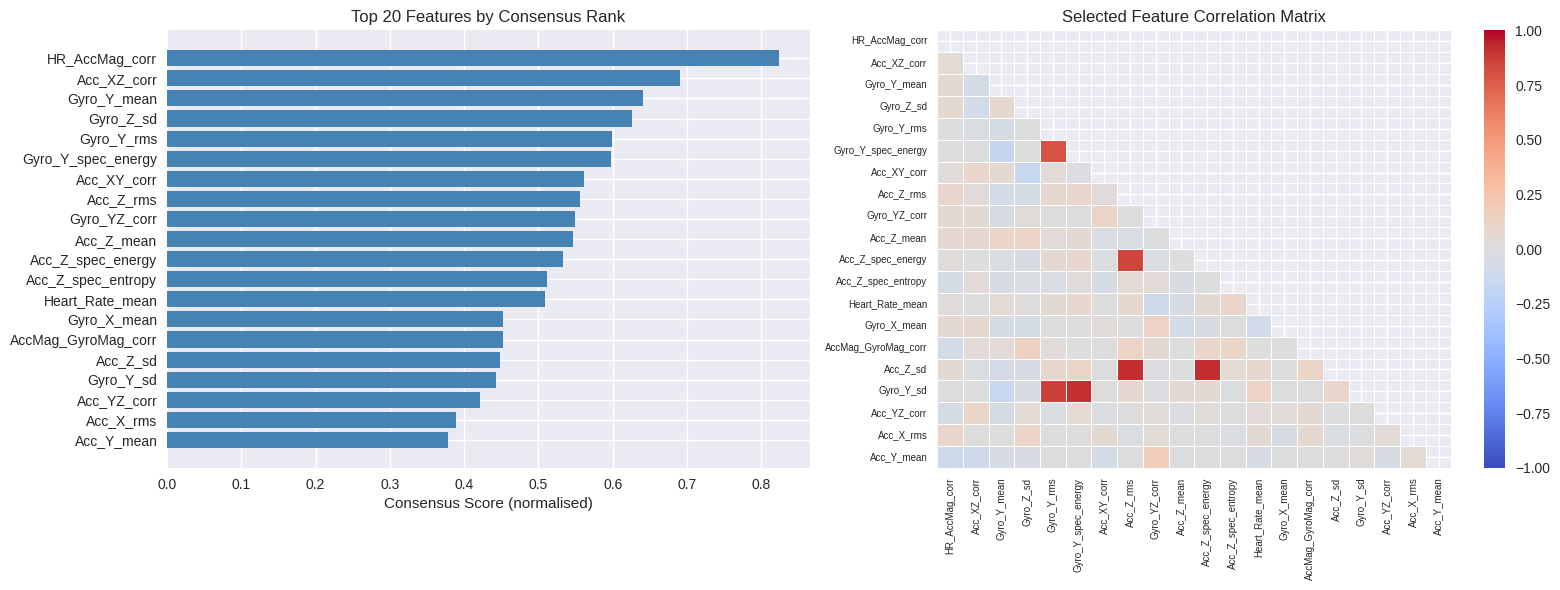

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Consensus score bar chart
axes[0].barh(ranking_df["feature"].iloc[:TOP_N][::-1],
             ranking_df["consensus"].iloc[:TOP_N][::-1],
             color="steelblue")
axes[0].set_xlabel("Consensus Score (normalised)")
axes[0].set_title(f"Top {TOP_N} Features by Consensus Rank")

# Correlation heatmap of selected features
corr_sel = df_features[selected_features].corr()
mask = np.triu(np.ones_like(corr_sel, dtype=bool))
sns.heatmap(corr_sel, mask=mask, ax=axes[1], cmap="coolwarm", center=0,
            vmin=-1, vmax=1, linewidths=0.4,
            xticklabels=selected_features, yticklabels=selected_features)
axes[1].set_title("Selected Feature Correlation Matrix")
axes[1].tick_params(axis="x", rotation=90, labelsize=7)
axes[1].tick_params(axis="y", rotation=0,  labelsize=7)

plt.tight_layout()
plt.savefig(S5 / "plots" / "feature_ranking_and_correlation.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close("all")


# PART 4: MODEL TRAINING AND HYPERPARAMETER TUNING

This section covers:
- Model selection: five candidate classifiers chosen for small tabular multi-class data
- Training pipeline: StandardScaler → SelectKBest (mutual information) → Classifier
- Cross-validation: 5-Fold Stratified CV and Leave-One-Athlete-Out (LOAO)
- Hyperparameter tuning: GridSearchCV for each model
- Saving all tuned models and a summary table for downstream evaluation

## IMPORTS FOR MODELING

In [36]:
import pickle
import warnings
warnings.filterwarnings("ignore")

from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold, LeaveOneGroupOut, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.dummy import DummyClassifier

MODEL_DIR = OUT_DIR / "saved_models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("Modeling imports ready.")
print(f"Models will be saved to: {MODEL_DIR.resolve()}")


Modeling imports ready.
Models will be saved to: /content/out/saved_models


### Prepare Feature Matrix, Labels, and Groups

We use the engineered feature matrix produced in Part 3 (`df_selected`). Meta columns are dropped, labels are integer-encoded, and athlete IDs are kept as group labels for Leave-One-Athlete-Out CV.

In [37]:
META_COLS = ["Athlete_ID", "window_start", "window_end",
             "window_seconds", "step_seconds", "n_samples", "label_purity"]

X      = df_features.drop(columns=META_COLS + ["Event_Label"], errors="ignore").values
y_raw  = df_features["Event_Label"].values
y_enc  = le.fit_transform(y_raw)
groups = df_features["Athlete_ID"].values

print(f"X      : {X.shape}")
print(f"y_enc  : {y_enc.shape}  classes: {list(le.classes_)}")
print(f"groups : {len(groups)}  athletes: {sorted(set(groups))}")


X      : (580, 57)
y_enc  : (580,)  classes: ['accel', 'jump_takeoff', 'landing', 'sprint_mid', 'start_run', 'stop']
groups : 580  athletes: ['A001', 'A002', 'A003', 'A004', 'A005']


### Train/Test Split & Feature Scaling

A stratified 80/20 split preserves class proportions in both sets. `StandardScaler` is fit on `X_train` only and applied to both splits, this prevents any test-set statistics from leaking into the training pipeline. The scaled arrays `X_train_sc` and `X_test_sc` are the input for all six classical models.

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test, groups_train, groups_test = train_test_split(
    X, y_enc, groups,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_enc,
)

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"X_train : {X_train_sc.shape}  |  X_test : {X_test_sc.shape}")
print(f"y_train : {len(y_train)}       |  y_test : {len(y_test)}")
print()
print("Class distribution — train:")
for cls, cnt in zip(*np.unique(y_train, return_counts=True)):
    print(f"  {le.classes_[cls]:>15} : {cnt}")
print("Class distribution — test:")
for cls, cnt in zip(*np.unique(y_test, return_counts=True)):
    print(f"  {le.classes_[cls]:>15} : {cnt}")


X_train : (464, 57)  |  X_test : (116, 57)
y_train : 464       |  y_test : 116

Class distribution — train:
            accel : 70
     jump_takeoff : 71
          landing : 54
       sprint_mid : 68
        start_run : 104
             stop : 97
Class distribution — test:
            accel : 17
     jump_takeoff : 18
          landing : 14
       sprint_mid : 17
        start_run : 26
             stop : 24


### Cross-Validation Strategy

Two CV strategies are used at different stages:

| Strategy | Data | Purpose |
|---|---|---|
| **Stratified 5-fold** | `X_train_sc` / `X_test_sc` | Model comparison — stable F1-macro estimates with preserved class proportions |
| **Leave-One-Athlete-Out (LOSO)** | Full `X`, scaled per fold | Generalisation — train on 4 athletes, test on the 5th unseen athlete |

These are kept strictly separate. The random 80/20 split mixes athletes across train and test, so it cannot be used for LOSO. For LOSO, `StandardScaler` is fit inside each fold on the training athletes only to prevent any test-athlete statistics from leaking into training.

In [39]:
# --- Strategy 1: Stratified 5-fold (on 80/20 split) ---
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print("Strategy 1 — Stratified 5-fold")
print(f"  Train : {X_train_sc.shape}  |  Test : {X_test_sc.shape}")
print(f"  Splits: {skf.get_n_splits(X_train_sc, y_train)}")

# --- Strategy 2: Leave-One-Athlete-Out (on full dataset, scaler fit per fold) ---
logo = LeaveOneGroupOut()

# Scale full X once for inspection, but per-fold scaling happens inside model eval loops
scaler_full = StandardScaler()
X_sc        = scaler_full.fit_transform(X)

print()
print("Strategy 2 — Leave-One-Athlete-Out (LOSO)")
print(f"  Full dataset : {X_sc.shape}")
print(f"  Folds        : {logo.get_n_splits(X_sc, y_enc, groups)}")
for fold, (tr, te) in enumerate(logo.split(X_sc, y_enc, groups)):
    held_out = np.unique(groups[te])[0]
    print(f"  Fold {fold+1}: train on {sorted(set(groups[tr]))}  →  test on [{held_out}]  ({len(te)} samples)")


Strategy 1 — Stratified 5-fold
  Train : (464, 57)  |  Test : (116, 57)
  Splits: 5

Strategy 2 — Leave-One-Athlete-Out (LOSO)
  Full dataset : (580, 57)
  Folds        : 5
  Fold 1: train on ['A002', 'A003', 'A004', 'A005']  →  test on [A001]  (116 samples)
  Fold 2: train on ['A001', 'A003', 'A004', 'A005']  →  test on [A002]  (116 samples)
  Fold 3: train on ['A001', 'A002', 'A004', 'A005']  →  test on [A003]  (116 samples)
  Fold 4: train on ['A001', 'A002', 'A003', 'A005']  →  test on [A004]  (116 samples)
  Fold 5: train on ['A001', 'A002', 'A003', 'A004']  →  test on [A005]  (116 samples)


### Baseline: Dummy Classifier

Establishes the performance floor that every real model must beat. With 6 roughly balanced classes, chance accuracy is ~16.7%. A `most_frequent` dummy is evaluated under both CV strategies — any model scoring below these baselines is worse than random guessing.

In [40]:
dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)

dummy_skf  = cross_val_score(dummy, X_sc, y_enc, cv=skf,  scoring="accuracy")
dummy_logo = cross_val_score(dummy, X_sc, y_enc, cv=logo, scoring="accuracy", groups=groups)

chance = 1 / len(le.classes_)
print(f"Chance level (uniform) : {chance:.3f}")
print(f"Dummy 5-fold  accuracy : {dummy_skf.mean():.3f} ± {dummy_skf.std():.3f}")
print(f"Dummy LOSO    accuracy : {dummy_logo.mean():.3f} ± {dummy_logo.std():.3f}")

DUMMY_BASELINE_SKF  = dummy_skf.mean()
DUMMY_BASELINE_LOSO = dummy_logo.mean()


Chance level (uniform) : 0.167
Dummy 5-fold  accuracy : 0.224 ± 0.000
Dummy LOSO    accuracy : 0.193 ± 0.062


Model Selection

In [41]:
def make_selector():
    return SelectKBest(f_classif, k=TOP_N)

candidate_models = {
    "Random Forest": Pipeline([("selector", make_selector()), ("clf", RandomForestClassifier(
        n_estimators=600, random_state=RANDOM_STATE, class_weight="balanced"
    ))]),
    "SVM-RBF": Pipeline([("selector", make_selector()), ("clf", SVC(
        kernel="rbf", random_state=RANDOM_STATE, class_weight="balanced"
    ))]),
    "Decision Tree": Pipeline([("selector", make_selector()), ("clf", DecisionTreeClassifier(
        max_depth=5, random_state=RANDOM_STATE, class_weight="balanced"
    ))]),
    "Naive Bayes": Pipeline([("selector", make_selector()), ("clf", GaussianNB(
        var_smoothing=1e-9
    ))]),
    "AdaBoost": Pipeline([("selector", make_selector()), ("clf", AdaBoostClassifier(
        n_estimators=100, learning_rate=0.1, random_state=RANDOM_STATE
    ))]),
    "XGBoost": Pipeline([("selector", make_selector()), ("clf", XGBClassifier(
        objective="multi:softmax", num_class=6,
        random_state=RANDOM_STATE, eval_metric="mlogloss", verbosity=0
    ))]),
    "MLP": Pipeline([("selector", make_selector()), ("clf", MLPClassifier(
        hidden_layer_sizes=(128, 64), max_iter=300, random_state=RANDOM_STATE
    ))]),
}

print("Candidate models:")
for name in candidate_models:
    print(f"  • {name}")

Candidate models:
  • Random Forest
  • SVM-RBF
  • Decision Tree
  • Naive Bayes
  • AdaBoost
  • XGBoost
  • MLP


### Pre-Tuning Baseline Evaluation

All candidate models are evaluated with default settings under both CV schemes to identify which are worth the additional tuning effort. Scores are compared against the dummy baseline.

In [42]:
baseline_results = []

for name, clf in candidate_models.items():
    skf_scores  = cross_val_score(clf, X_train_sc, y_train, cv=skf,  scoring="accuracy")
    logo_scores = cross_val_score(clf, X_train_sc, y_train, cv=logo, scoring="accuracy", groups=groups_train)

    baseline_results.append({
        "Model":       name,
        "5-Fold Mean": round(skf_scores.mean(),  4),
        "5-Fold Std":  round(skf_scores.std(),   4),
        "LOSO Mean":   round(logo_scores.mean(), 4),
        "LOSO Std":    round(logo_scores.std(),  4),
    })
    print(f"{name:25s} | 5-Fold: {skf_scores.mean():.3f} ± {skf_scores.std():.3f} "
          f"| LOSO: {logo_scores.mean():.3f} ± {logo_scores.std():.3f}")

baseline_df = pd.DataFrame(baseline_results).set_index("Model")
display(baseline_df)
baseline_df.to_csv(S6 / "tables" / "baseline_scores.csv")
print("Dummy baselines — 5-Fold: {:.3f}  |  LOSO: {:.3f}".format(
    DUMMY_BASELINE_SKF, DUMMY_BASELINE_LOSO))

Random Forest             | 5-Fold: 0.298 ± 0.055 | LOSO: 0.170 ± 0.030
SVM-RBF                   | 5-Fold: 0.287 ± 0.046 | LOSO: 0.142 ± 0.035
Decision Tree             | 5-Fold: 0.168 ± 0.020 | LOSO: 0.157 ± 0.044
Naive Bayes               | 5-Fold: 0.241 ± 0.035 | LOSO: 0.150 ± 0.029
AdaBoost                  | 5-Fold: 0.246 ± 0.041 | LOSO: 0.218 ± 0.040
XGBoost                   | 5-Fold: 0.244 ± 0.036 | LOSO: 0.196 ± 0.044
MLP                       | 5-Fold: 0.302 ± 0.041 | LOSO: 0.150 ± 0.048


,5-Fold Mean,5-Fold Std,LOSO Mean,LOSO Std
Model,,,,
Random Forest,0.2976,0.0548,0.1700,0.0298
SVM-RBF,0.2867,0.0462,0.1415,0.0349
Decision Tree,0.1681,0.0197,0.1567,0.0444
Naive Bayes,0.2414,0.0345,0.1505,0.0293
AdaBoost,0.2457,0.0409,0.2183,0.0399
XGBoost,0.2436,0.0359,0.1957,0.0442
MLP,0.3018,0.0410,0.1499,0.0483


Dummy baselines — 5-Fold: 0.224  |  LOSO: 0.193


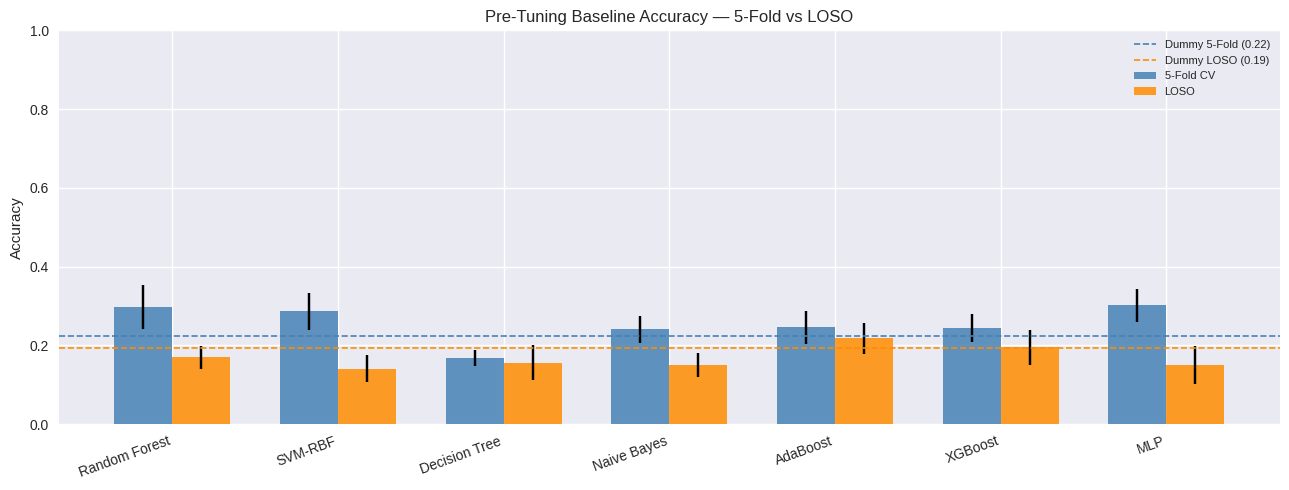

In [43]:
models_list = baseline_df.index.tolist()
x = np.arange(len(models_list))
w = 0.35

fig, ax = plt.subplots(figsize=(13, 5))

ax.bar(x - w/2, baseline_df["5-Fold Mean"], w,
       yerr=baseline_df["5-Fold Std"], capsize=4,
       color="steelblue", alpha=0.85, label="5-Fold CV")
ax.bar(x + w/2, baseline_df["LOSO Mean"], w,
       yerr=baseline_df["LOSO Std"], capsize=4,
       color="darkorange", alpha=0.85, label="LOSO")

ax.axhline(DUMMY_BASELINE_SKF,  color="steelblue", linestyle="--", linewidth=1.2,
           label=f"Dummy 5-Fold ({DUMMY_BASELINE_SKF:.2f})")
ax.axhline(DUMMY_BASELINE_LOSO, color="darkorange", linestyle="--", linewidth=1.2,
           label=f"Dummy LOSO ({DUMMY_BASELINE_LOSO:.2f})")

ax.set_xticks(x)
ax.set_xticklabels(models_list, rotation=20, ha="right")
ax.set_ylabel("Accuracy")
ax.set_title("Pre-Tuning Baseline Accuracy — 5-Fold vs LOSO")
ax.set_ylim(0, 1.0)
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(S6 / "plots" / "pretuning_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close("all")


### Hyperparameter Tuning

## Random Forest

In [44]:
rf_gs = GridSearchCV(
    Pipeline([('selector', make_selector()), ('clf', RandomForestClassifier(random_state=RANDOM_STATE, class_weight='balanced'))]),
    {
        'clf__n_estimators':     [100, 200, 300, 500],
        'clf__max_depth':        [None, 10, 20, 30],
        'clf__min_samples_leaf': [1, 2, 4],
    },
    cv=skf, scoring='accuracy', n_jobs=-1, refit=True, verbose=1
)

rf_gs.fit(X_train_sc, y_train)

print(f'\nBest CV accuracy : {rf_gs.best_score_:.4f}')
print(f'Best params      : {rf_gs.best_params_}')

with open(MODEL_DIR / 'random_forest_tuned.pkl', 'wb') as f:
    pickle.dump(rf_gs.best_estimator_, f)
print('Model saved.')


Fitting 5 folds for each of 48 candidates, totalling 240 fits

Best CV accuracy : 0.3083
Best params      : {'clf__max_depth': 10, 'clf__min_samples_leaf': 4, 'clf__n_estimators': 100}
Model saved.


### Hyperparameter Tuning — SVM (RBF Kernel)

In [45]:
svm_gs = GridSearchCV(
    Pipeline([("selector", make_selector()), ("clf", SVC(kernel="rbf", random_state=RANDOM_STATE, class_weight="balanced"))]),
    {
        "clf__C":     [0.1, 1, 10, 100, 1000],
        "clf__gamma": ["scale", "auto", 0.01, 0.001],
    },
    cv=skf, scoring="accuracy", n_jobs=-1, refit=True, verbose=1
)

svm_gs.fit(X_train_sc, y_train)

print(f"\nBest CV accuracy : {svm_gs.best_score_:.4f}")
print(f"Best params      : {svm_gs.best_params_}")

with open(MODEL_DIR / "svm_rbf_tuned.pkl", "wb") as f:
    pickle.dump(svm_gs.best_estimator_, f)
print("Model saved.")

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best CV accuracy : 0.3124
Best params      : {'clf__C': 10, 'clf__gamma': 'scale'}
Model saved.


### Hyperparameter Tuning — Decision Tree

In [46]:
dt_gs = GridSearchCV(
    Pipeline([("selector", make_selector()), ("clf", DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight="balanced"))]),
    {
        "clf__max_depth":        [3, 5, 10, 15, None],
        "clf__min_samples_leaf": [1, 2, 4, 8],
        "clf__criterion":        ["gini", "entropy"],
    },
    cv=skf, scoring="accuracy", n_jobs=-1, refit=True, verbose=1
)

dt_gs.fit(X_train_sc, y_train)

print("Best CV accuracy :", round(dt_gs.best_score_, 4))
print("Best params      :", dt_gs.best_params_)

with open(MODEL_DIR / "decision_tree_tuned.pkl", "wb") as f:
    pickle.dump(dt_gs.best_estimator_, f)
print("Model saved.")

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best CV accuracy : 0.2263
Best params      : {'clf__criterion': 'gini', 'clf__max_depth': 15, 'clf__min_samples_leaf': 8}
Model saved.


### Hyperparameter Tuning — Naive Bayes

In [47]:
nb_gs = GridSearchCV(
    Pipeline([("selector", make_selector()), ("clf", GaussianNB())]),
    {
        "clf__var_smoothing": [1e-11, 1e-10, 1e-9, 1e-8, 1e-7, 1e-6],
    },
    cv=skf, scoring="accuracy", n_jobs=-1, refit=True, verbose=1
)

nb_gs.fit(X_train_sc, y_train)

print("Best CV accuracy :", round(nb_gs.best_score_, 4))
print("Best params      :", nb_gs.best_params_)

with open(MODEL_DIR / "naive_bayes_tuned.pkl", "wb") as f:
    pickle.dump(nb_gs.best_estimator_, f)
print("Model saved.")

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best CV accuracy : 0.2414
Best params      : {'clf__var_smoothing': 1e-11}
Model saved.


### Hyperparameter Tuning — AdaBoost

In [48]:
ada_gs = GridSearchCV(
    Pipeline([("selector", make_selector()), ("clf", AdaBoostClassifier(random_state=RANDOM_STATE))]),
    {
        "clf__n_estimators":  [50, 100, 200, 300],
        "clf__learning_rate": [0.01, 0.1, 0.5, 1.0],
    },
    cv=skf, scoring="accuracy", n_jobs=-1, refit=True, verbose=1
)

ada_gs.fit(X_train_sc, y_train)

print("Best CV accuracy :", round(ada_gs.best_score_, 4))
print("Best params      :", ada_gs.best_params_)

with open(MODEL_DIR / "adaboost_tuned.pkl", "wb") as f:
    pickle.dump(ada_gs.best_estimator_, f)
print("Model saved.")

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best CV accuracy : 0.2458
Best params      : {'clf__learning_rate': 0.01, 'clf__n_estimators': 300}
Model saved.


### Hyperparameter Tuning — XGBoost

In [49]:
xgb_gs = GridSearchCV(
    Pipeline([("selector", make_selector()), ("clf", XGBClassifier(
        objective="multi:softmax",
        num_class=len(le.classes_),
        random_state=RANDOM_STATE,
        eval_metric="mlogloss",
        verbosity=0,
    ))]),
    {
        "clf__n_estimators":  [200, 400, 600],   # higher ceiling so lr=0.05 has enough trees to converge
        "clf__max_depth":     [3, 5, 7],
        "clf__learning_rate": [0.05, 0.1, 0.2],
        "clf__subsample":     [0.7, 0.85, 1.0],
    },
    cv=skf, scoring="accuracy", n_jobs=-1, refit=True, verbose=1
)

xgb_gs.fit(X_train_sc, y_train)

print("Best CV accuracy :", round(xgb_gs.best_score_, 4))
print("Best params      :", xgb_gs.best_params_)

with open(MODEL_DIR / "xgboost_tuned.pkl", "wb") as f:
    pickle.dump(xgb_gs.best_estimator_, f)
print("Model saved.")

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best CV accuracy : 0.291
Best params      : {'clf__learning_rate': 0.05, 'clf__max_depth': 5, 'clf__n_estimators': 400, 'clf__subsample': 0.85}
Model saved.


### Hyperparameter Tuning — MLP

In [50]:
mlp_gs = GridSearchCV(
    Pipeline([("selector", make_selector()), ("clf", MLPClassifier(max_iter=500, random_state=RANDOM_STATE))]),
    {
        "clf__hidden_layer_sizes": [(64,), (128,), (64, 32), (128, 64)],
        "clf__learning_rate_init": [0.001, 0.01],
        "clf__alpha":              [0.0001, 0.001, 0.01],
    },
    cv=skf, scoring="accuracy", n_jobs=-1, refit=True, verbose=1
)

mlp_gs.fit(X_train_sc, y_train)

print("Best CV accuracy :", round(mlp_gs.best_score_, 4))
print("Best params      :", mlp_gs.best_params_)

with open(MODEL_DIR / "mlp_tuned.pkl", "wb") as f:
    pickle.dump(mlp_gs.best_estimator_, f)
print("Model saved.")

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best CV accuracy : 0.3083
Best params      : {'clf__alpha': 0.0001, 'clf__hidden_layer_sizes': (128, 64), 'clf__learning_rate_init': 0.01}
Model saved.


### Hyperparameter Tuning Summary

Collects best CV accuracy and best parameters from all tuned models.

,Best CV Accuracy,Best Params
Model,,
SVM-RBF,0.3124,"{'clf__C': 10, 'clf__gamma': 'scale'}"
Random Forest,0.3083,"{'clf__max_depth': 10, 'clf__min_samples_leaf'..."
MLP,0.3083,"{'clf__alpha': 0.0001, 'clf__hidden_layer_size..."
XGBoost,0.2910,"{'clf__learning_rate': 0.05, 'clf__max_depth':..."
AdaBoost,0.2458,"{'clf__learning_rate': 0.01, 'clf__n_estimator..."
Naive Bayes,0.2414,{'clf__var_smoothing': 1e-11}
Decision Tree,0.2263,"{'clf__criterion': 'gini', 'clf__max_depth': 1..."


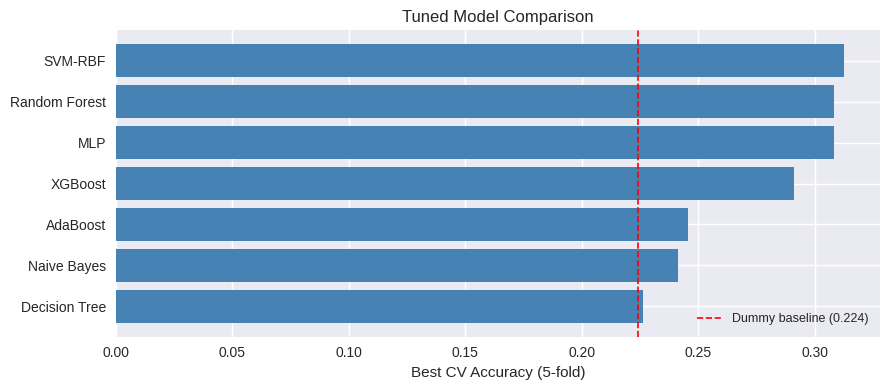

Saved tuning_summary.csv and tuning_summary.png


In [51]:
tuned_models = {
    "Random Forest":  rf_gs,
    "SVM-RBF":        svm_gs,
    "Decision Tree":  dt_gs,
    "Naive Bayes":    nb_gs,
    "AdaBoost":       ada_gs,
    "XGBoost":        xgb_gs,
    "MLP":            mlp_gs,
}

summary_rows = []
for name, gs in tuned_models.items():
    summary_rows.append({
        "Model":            name,
        "Best CV Accuracy": round(gs.best_score_, 4),
        "Best Params":      gs.best_params_,
    })

tuning_summary_df = (
    pd.DataFrame(summary_rows)
    .set_index("Model")
    .sort_values("Best CV Accuracy", ascending=False)
)

display(tuning_summary_df)
tuning_summary_df.to_csv(S6 / "tables" / "tuning_summary.csv")

# Bar chart
fig, ax = plt.subplots(figsize=(9, 4))
colors = ["steelblue" if v > DUMMY_BASELINE_SKF else "salmon"
          for v in tuning_summary_df["Best CV Accuracy"]]
ax.barh(tuning_summary_df.index[::-1], tuning_summary_df["Best CV Accuracy"][::-1],
        color=colors[::-1])
ax.axvline(DUMMY_BASELINE_SKF, color="red", linestyle="--", linewidth=1.2,
           label=f"Dummy baseline ({DUMMY_BASELINE_SKF:.3f})")
ax.set_xlabel("Best CV Accuracy (5-fold)")
ax.set_title("Tuned Model Comparison")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(S6 / "plots" / "tuning_summary.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close("all")
print("Saved tuning_summary.csv and tuning_summary.png")


### Pre-Tuning vs Post-Tuning Accuracy

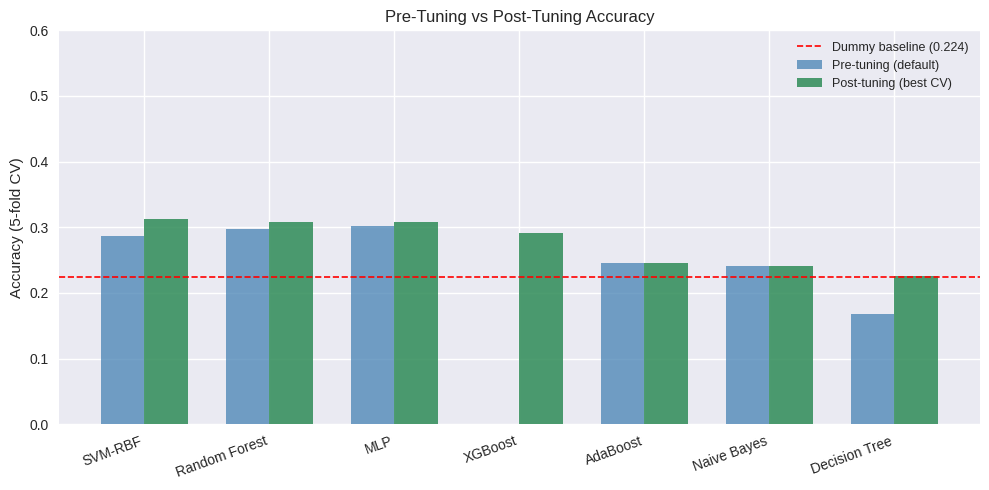

Saved pretuning_vs_posttuning.png


In [52]:
pre_lookup = {
    "Random Forest":  baseline_df.loc["Random Forest",  "5-Fold Mean"],
    "SVM-RBF":        baseline_df.loc["SVM-RBF",        "5-Fold Mean"],
    "Decision Tree":  baseline_df.loc["Decision Tree",  "5-Fold Mean"],
    "Naive Bayes":    baseline_df.loc["Naive Bayes",    "5-Fold Mean"],
    "AdaBoost":       baseline_df.loc["AdaBoost",       "5-Fold Mean"],
    "XGBoost":        float("nan"),
    "MLP":            baseline_df.loc["MLP",            "5-Fold Mean"],
}

models_ordered = tuning_summary_df.index.tolist()
pre_vals  = [pre_lookup.get(m, float("nan")) for m in models_ordered]
post_vals = tuning_summary_df["Best CV Accuracy"].tolist()

x = np.arange(len(models_ordered))
w = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w/2, pre_vals,  w, label="Pre-tuning (default)",  color="steelblue", alpha=0.75)
ax.bar(x + w/2, post_vals, w, label="Post-tuning (best CV)", color="seagreen",  alpha=0.85)
ax.axhline(DUMMY_BASELINE_SKF, color="red", linestyle="--", linewidth=1.2,
           label=f"Dummy baseline ({DUMMY_BASELINE_SKF:.3f})")
ax.set_xticks(x)
ax.set_xticklabels(models_ordered, rotation=20, ha="right")
ax.set_ylabel("Accuracy (5-fold CV)")
ax.set_title("Pre-Tuning vs Post-Tuning Accuracy")
ax.set_ylim(0, 0.6)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(S6 / "plots" / "pretuning_vs_posttuning.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close("all")
print("Saved pretuning_vs_posttuning.png")


## PART 5: DEEP LEARNING PIPELINE EXTENSION

The scaled feature matrix is used directly to train a feedforward ANN.
No reshaping is needed — input shape is `(N, F)` where F is the number
of selected features.


### Input Reshaping & Array Export

Format and save train/test arrays for all three architectures.

In [53]:
import numpy as np

n_train, n_features = X_train_sc.shape
n_test              = X_test_sc.shape[0]
n_classes           = len(le.classes_)

print('Input shape summary')
print(f'  Features (F)     : {n_features}')
print(f'  Classes          : {n_classes}  → {list(le.classes_)}')
print(f'  Train samples    : {n_train}')
print(f'  Test  samples    : {n_test}')
print()

# Feedforward ANN input — already (N, F), no reshaping needed
X_train_ann = X_train_sc
X_test_ann  = X_test_sc

print(f'ANN train: {X_train_ann.shape}  |  test: {X_test_ann.shape}')
print()

# Save arrays
for name, arr in {
    'X_train_ann': X_train_ann,
    'X_test_ann':  X_test_ann,
    'y_train':     y_train,
    'y_test':      y_test,
}.items():
    path = S6 / 'tables' / f'{name}.npy'
    np.save(path, arr)
    print(f'  Saved {name}.npy  {arr.shape}')


Input shape summary
  Features (F)     : 57
  Classes          : 6  → ['accel', 'jump_takeoff', 'landing', 'sprint_mid', 'start_run', 'stop']
  Train samples    : 464
  Test  samples    : 116

ANN train: (464, 57)  |  test: (116, 57)

  Saved X_train_ann.npy  (464, 57)
  Saved X_test_ann.npy  (116, 57)
  Saved y_train.npy  (464,)
  Saved y_test.npy  (116,)


### Sequence Preparation — ANN Input Pipeline

Confirms and documents every step of the input pipeline before model construction:

| Step | Decision | Detail |
|---|---|---|
| **Normalization** | Per-athlete z-score → global `StandardScaler` | Applied in preprocessing; scaler fit on train only |
| **Label encoding** | Integer (`LabelEncoder`) | Matches classical models; one-hot available if needed |
| **Train/test split** | Stratified 80/20 | Identical split used for classical models |
| **Input tensor** | `(N, 25)` flat | Feedforward ANN; LSTM/CNN variants in reshaped arrays |
| **Output units** | 6 | One per motion phase class |
| **Loss** | Sparse categorical cross-entropy | Works directly with integer labels |

In [54]:
# Confirm pipeline state
print("=== ANN Input Pipeline Verification ===")
print()
print("1. Normalization")
print(f"   Per-athlete z-score applied in preprocessing")
print(f"   StandardScaler fit on X_train only — no leakage")
print(f"   Train mean ≈ {X_train_sc.mean():.4f}  std ≈ {X_train_sc.std():.4f}")
print(f"   Test  mean ≈ {X_test_sc.mean():.4f}  std ≈ {X_test_sc.std():.4f}")
print()
print("2. Label Encoding")
print(f"   Strategy : integer (LabelEncoder)")
print(f"   Classes  : {list(enumerate(le.classes_))}")
print(f"   One-hot alternative : tf.keras.utils.to_categorical(y, num_classes={len(le.classes_)})")
print()
print("3. Train / Test Split")
print(f"   Strategy : stratified 80/20  (random_state={RANDOM_STATE})")
print(f"   Train    : {X_train_sc.shape[0]} samples")
print(f"   Test     : {X_test_sc.shape[0]} samples")
print(f"   Matches classical model split : YES")
print()
print("4. Input Tensor Shapes")
print(f"   Feedforward ANN : {X_train_ann.shape}   → input_shape=({X_train_ann.shape[1]},)")

print()
print("5. Output Layer")
print(f"   Units      : {len(le.classes_)}")
print(f"   Activation : softmax")
print(f"   Loss       : sparse_categorical_crossentropy")
print(f"   Metric     : accuracy")


=== ANN Input Pipeline Verification ===

1. Normalization
   Per-athlete z-score applied in preprocessing
   StandardScaler fit on X_train only — no leakage
   Train mean ≈ 0.0000  std ≈ 1.0000
   Test  mean ≈ -0.0187  std ≈ 1.0139

2. Label Encoding
   Strategy : integer (LabelEncoder)
   Classes  : [(0, 'accel'), (1, 'jump_takeoff'), (2, 'landing'), (3, 'sprint_mid'), (4, 'start_run'), (5, 'stop')]
   One-hot alternative : tf.keras.utils.to_categorical(y, num_classes=6)

3. Train / Test Split
   Strategy : stratified 80/20  (random_state=42)
   Train    : 464 samples
   Test     : 116 samples
   Matches classical model split : YES

4. Input Tensor Shapes
   Feedforward ANN : (464, 57)   → input_shape=(57,)

5. Output Layer
   Units      : 6
   Activation : softmax
   Loss       : sparse_categorical_crossentropy
   Metric     : accuracy


### ANN/MLP — Model Definition & Training

A feedforward neural network trained on the prepared `X_train_ann` arrays. Architecture: two hidden layers (128 → 64) with ReLU, batch normalisation, and dropout for regularisation. Output: 6-unit softmax. Trained with early stopping to prevent overfitting.

In [55]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

tf.random.set_seed(RANDOM_STATE)

n_features = X_train_ann.shape[1]
n_classes  = len(le.classes_)

def build_ann(input_dim, n_classes, dropout=0.3):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(dropout),
        layers.Dense(64, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(dropout),
        layers.Dense(n_classes, activation="softmax"),
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

ann_model = build_ann(n_features, n_classes)
ann_model.summary()

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=10, restore_best_weights=True
)

history = ann_model.fit(
    X_train_ann, y_train,
    validation_split=0.2,
    epochs=12,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1,
)

ann_model.save(MODEL_DIR / "ann_model.keras")
print("Model saved.")


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         7,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,838 (65.77 KB)

 Trainable params: 16,454 (64.27 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/12
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.1887 - loss: 2.5904 - val_accuracy: 0.1505 - val_loss: 1.8955
Epoch 2/12
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2183 - loss: 2.2424 - val_accuracy: 0.1935 - val_loss: 1.8637
Epoch 3/12
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.2480 - loss: 2.1058 - val_accuracy: 0.2043 - val_loss: 1.8454
Epoch 4/12
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3019 - loss: 1.7959 - val_accuracy: 0.1935 - val_loss: 1.8423
Epoch 5/12
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3450 - loss: 1.7722 - val_accuracy: 0.2043 - val_loss: 1.8451
Epoch 6/12
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3504 - loss: 1.6131 - val_accuracy: 0.2043 - val_loss: 1.8524
Epoch 7/12
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3747 - loss: 1.6075 - val_accuracy: 0.2043 - val_loss: 1.8629
Epoch 8/12
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4178 - loss: 1.4808 - val_accuracy: 0.2258 - val_los

### ANN — Training Curves & Test Evaluation

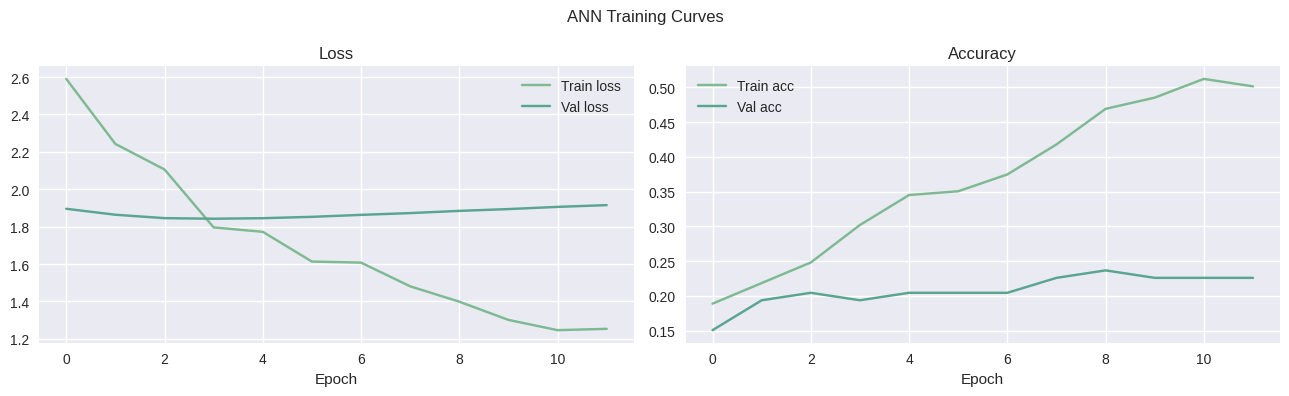

ANN Test Accuracy  : 0.2069
ANN Test Precision : 0.1688
ANN Test Recall    : 0.1854
ANN Test F1-macro  : 0.1655


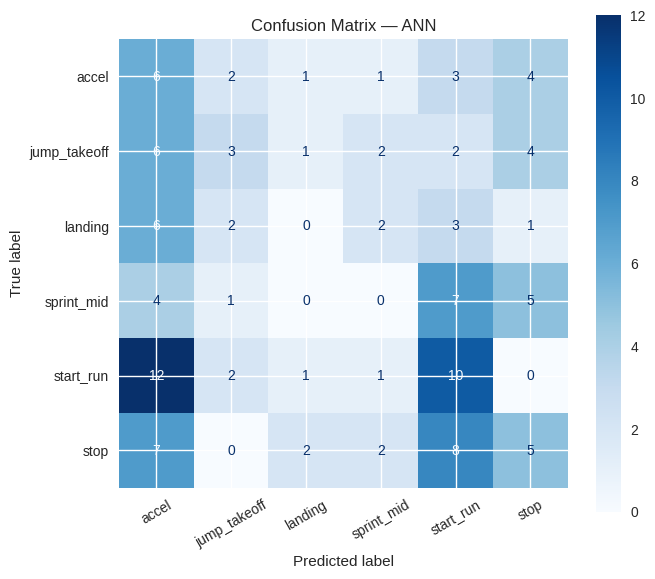

In [56]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history.history["loss"],     label="Train loss")
axes[0].plot(history.history["val_loss"], label="Val loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[1].plot(history.history["accuracy"],     label="Train acc")
axes[1].plot(history.history["val_accuracy"], label="Val acc")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()
plt.suptitle("ANN Training Curves", fontsize=12)
plt.tight_layout()
plt.savefig(S6 / "plots" / "ann_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close("all")

# Test set evaluation
y_pred_ann = np.argmax(ann_model.predict(X_test_ann, verbose=0), axis=1)

ann_acc  = accuracy_score(y_test, y_pred_ann)
ann_prec = precision_score(y_test, y_pred_ann, average="macro", zero_division=0)
ann_rec  = recall_score(y_test, y_pred_ann,    average="macro", zero_division=0)
ann_f1   = f1_score(y_test, y_pred_ann,        average="macro", zero_division=0)

print(f"ANN Test Accuracy  : {ann_acc:.4f}")
print(f"ANN Test Precision : {ann_prec:.4f}")
print(f"ANN Test Recall    : {ann_rec:.4f}")
print(f"ANN Test F1-macro  : {ann_f1:.4f}")

# Confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
cm = confusion_matrix(y_test, y_pred_ann, labels=np.arange(n_classes))
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(
    ax=ax, colorbar=True, cmap="Blues", xticks_rotation=30)
ax.set_title("Confusion Matrix — ANN")
plt.tight_layout()
plt.savefig(S6 / "plots" / "cm_ann.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close("all")


# Evaluation

In [57]:
### Imports
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, ConfusionMatrixDisplay

In [58]:
# Selecting best Tuned Model

bestTunedModel = tuning_summary_df["Best CV Accuracy"].idxmax() #Use max of index CV accuracy to find best accuracy
gridSearchBest = tuned_models[bestTunedModel] #Search tuned models for the best model
bestEstimator = gridSearchBest.best_estimator_    #Create estimator object to .fit() and .predict() on based off best model

print(f"Best tuned model: {bestTunedModel}")
print(f"Best grid search 5-fold CV after tuning: {gridSearchBest.best_score_:.4f}")

print("#---------- Best Tuned Model Parameters ----------#")
print(gridSearchBest.best_params_)

Best tuned model: SVM-RBF
Best grid search 5-fold CV after tuning: 0.3124
#---------- Best Tuned Model Parameters ----------#
{'clf__C': 10, 'clf__gamma': 'scale'}


## 5-Fold vs LOSO
Both strategies run on the scaled training split to avoid test set leakage. 5-Fold may overestimate performance since windows from the same athlete can appear in both train and test folds. LOSO holds out one athlete per fold, making it a stricter and more realistic estimate of generalisation to unseen athletes.

In [59]:
#Comparison between 5-Fold CV and LOSO

modelEvalResults = []

for name, gridSrch in tuned_models.items(): #Loop through tuned models
  estimator = gridSrch.best_estimator_ #Get the best version of each tuned model
  fold5Score = cross_val_score(estimator, X_train_sc, y_train, cv=skf, scoring="accuracy", n_jobs=-1)    #Evaluate 5-Fold CV on training split
  losoScore  = cross_val_score(estimator, X_train_sc, y_train, cv=logo, groups=groups_train, scoring="accuracy", n_jobs=-1)  #Evaluate LOSO on training split

  #Append evaluation results as dictionary with comparison results
  modelEvalResults.append({
      "Model": name,
      "5-Fold Mean": round(fold5Score.mean(), 4),
      "5-Fold std": round(fold5Score.std(), 4),
      "LOSO Mean": round(losoScore.mean(), 4),
      "LOSO std": round(losoScore.std(), 4),
      "5-Fold vs LOSO Difference": round(fold5Score.mean() - losoScore.mean(), 4)
  })

#Put the evaluation into a dataframe
evaluationDF = pd.DataFrame(modelEvalResults).sort_values(by=["LOSO Mean", "5-Fold Mean"], ascending=False).reset_index(drop=True)

display(evaluationDF) #Display results and save output to csv
evaluationDF.to_csv(S7 / "tables" / "5-Fold_vs_LOSO_Comparison.csv", index=False)

,Model,5-Fold Mean,5-Fold std,LOSO Mean,LOSO std,5-Fold vs LOSO Difference
0,AdaBoost,0.2458,0.0473,0.2187,0.0566,0.0271
1,XGBoost,0.2910,0.0236,0.1851,0.0398,0.1059
2,Decision Tree,0.2263,0.0175,0.1676,0.0288,0.0586
3,Random Forest,0.3083,0.0434,0.1656,0.0222,0.1428
4,SVM-RBF,0.3124,0.0423,0.1635,0.0300,0.1488
5,MLP,0.3083,0.0295,0.1627,0.0516,0.1455
6,Naive Bayes,0.2414,0.0345,0.1505,0.0293,0.0909


## Window Size Comparison Result Explanation
The first thing you will notice in our table of window sizes is that the last 4 window sizes are NaN in the means and std for both 5-Fold and LOSO. This is because while some windows may encapsulate data, there may not be enough groups or samples in the window. Such as 1.4 having 21 windows, since there may be only 1 class, it will fail to go through with Stratified Cross Validation. Resulting in NaN to be inputted.

In [60]:
###Window Size Comparisons
# Smaller windows = more samples but more noisy, Bigger windows = fewer samples but capture more context

windowSizes = [.2, .4, .6, .8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0] #10 windows in .2 second increments
windowSizeResults = [] #List to store results of each tested window size

bestClfTemplate = bestEstimator.named_steps["clf"].__class__ #Get the classifier class from the Pipeline
bestClassiferParameters = bestEstimator.named_steps["clf"].get_params() #Get all classifier params

for wndw in windowSizes: #Loop through all the window sizes
  #Remake the feature dataset but with the current window size.
  featureDF_windowSize = extract_window_features(df_clean, sampling_rate_hz=FS, window_seconds=wndw, step_ratio=STEP_RATIO, min_samples=1).copy()

  if featureDF_windowSize.empty: #If no windows extracted, store as NaN
    windowSizeResults.append({
      "Window Size (s)": wndw,
      "# of Windows": 0,
      "5-Fold Mean": np.nan,
      "5-Fold std": np.nan,
      "LOSO Mean": np.nan,
      "LOSO std": np.nan,
    })
    continue

  xWndw = featureDF_windowSize.drop(columns=META_COLS + ["Event_Label"], errors="ignore").copy() #Build features, labels and groups for the window size
  yWndwRaw = featureDF_windowSize["Event_Label"].copy()
  groupsWndw = featureDF_windowSize["Athlete_ID"].copy()
  yWndw = le.transform(yWndwRaw)

  classiferWndw = bestClfTemplate(**bestClassiferParameters) #Instantiate classifier with best params
  pipelineWndw = Pipeline([("selector", SelectKBest(f_classif, k=min(TOP_N, xWndw.shape[1]))), ("clf", classiferWndw)]) #Select features then classify

  numSamples = len(xWndw) #Set variables for safety check, ensures cross-validation errors dont occur from having not enough splits
  minClassCount = pd.Series(yWndw).value_counts().min()
  numGroups = len(pd.Series(groupsWndw).unique())

  if numSamples < 2 or minClassCount < 2: #Safety Check for splits
    windowSizeResults.append({
      "Window Size (s)": wndw,
      "# of Windows": int(numSamples),
      "5-Fold Mean": np.nan,
      "5-Fold std": np.nan,
      "LOSO Mean": np.nan,
      "LOSO std": np.nan,
    })
    continue

  foldsToUse = min(5, numSamples, minClassCount) #Use the most amount of folds (max 5)
  skfWndw = StratifiedKFold(n_splits=foldsToUse, shuffle=True, random_state=RANDOM_STATE)

  fold5ScoreWndw = cross_val_score(pipelineWndw, xWndw, yWndw, cv=skfWndw, scoring="accuracy") #Evaluate 5-Fold CV

  if numGroups >= 2: #Run LOSO only if there are at least 2 unique athletes
    losoScoreWndw = cross_val_score(pipelineWndw, xWndw, yWndw, cv=logo, groups=groupsWndw, scoring="accuracy")
    losoMean = round(losoScoreWndw.mean(), 4)
    losoStd = round(losoScoreWndw.std(), 4)
  else:
    losoMean = np.nan
    losoStd = np.nan

  windowSizeResults.append({ #Save results for this window size
      "Window Size (s)": wndw,
      "# of Windows": int(len(featureDF_windowSize)),
      "5-Fold Mean": round(fold5ScoreWndw.mean(), 4),
      "5-Fold std": round(fold5ScoreWndw.std(), 4),
      "LOSO Mean": losoMean,
      "LOSO std": losoStd
    })

windowSizeDF = pd.DataFrame(windowSizeResults)
display(windowSizeDF)

windowSizeDF.to_csv(S7 / "tables" / "windowSizeComparison.csv", index=False)

,Window Size (s),# of Windows,5-Fold Mean,5-Fold std,LOSO Mean,LOSO std
0,0.2,1490,0.1698,0.0243,0.1436,0.0109
1,0.4,1480,0.2230,0.0037,0.1682,0.0162
2,0.6,980,0.2469,0.0223,0.1704,0.0333
3,0.8,730,0.2507,0.0240,0.1904,0.0391
4,1.0,580,0.2138,0.0301,0.1586,0.0372
5,1.2,480,0.1979,0.0401,0.1375,0.0783
6,1.4,410,0.2171,0.0432,0.1122,0.0425
7,1.6,355,0.2507,0.0422,0.2056,0.0191
8,1.8,315,0.2190,0.0254,0.1651,0.0685
9,2.0,280,0.2321,0.0565,0.1571,0.0709


# Best Model Windowing Accuracy
Contrary to previous assumptions, in this graph we find that 5-Fold Cross validation performed better for accuracy. This accuracy became better when the window sizes became larger, meaning that larger window sizes capture motion better. In almost every window 5-Fold CV had a better accuracy than LOSO which tells us the model performs better when data with the same athletes appear in training.

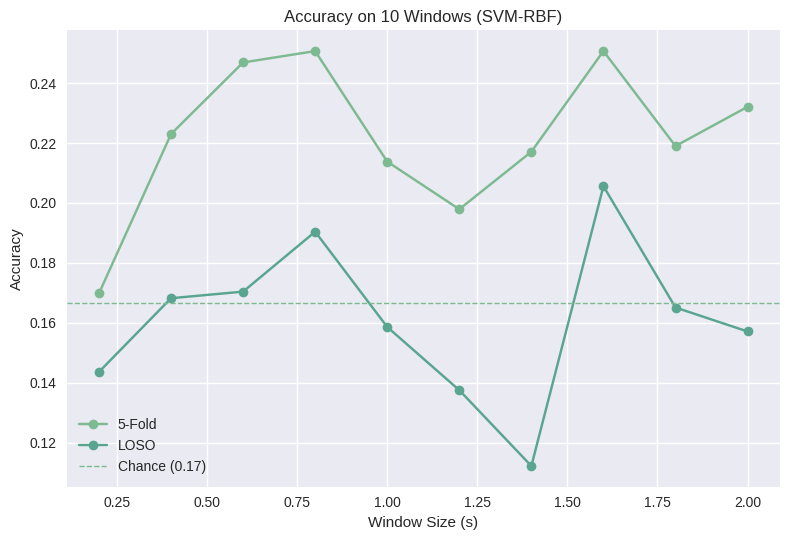

In [74]:
###Plotting window size comparisons
plt.plot(windowSizeDF["Window Size (s)"], windowSizeDF["5-Fold Mean"], marker="o", label="5-Fold") #Plots 5-Fold performance for window sizes
plt.plot(windowSizeDF["Window Size (s)"], windowSizeDF["LOSO Mean"], marker="o", label="LOSO") #Plots LOSO performance for window sizes
plt.axhline(chance, linestyle="--", linewidth=1, label=f"Chance ({chance:.2f})") #Chance = random guessing accuracy (Baseline)

plt.xlabel("Window Size (s)")
plt.ylabel("Accuracy")
plt.title(f"Accuracy on 10 Windows ({bestTunedModel})")
plt.legend()
plt.tight_layout()
plt.savefig(S7 / "plots" / "window_size_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## Metrics

In [62]:
### Best Tuned Model Metrics

yPred5Fold = cross_val_predict(bestEstimator, X_train_sc, y_train, cv=skf)
yPredLOSO = cross_val_predict(bestEstimator, X_train_sc, y_train, cv=logo, groups=groups_train)

def buildMetricsTable(yTrue, yPred, splitName): #Function to generate per-class metrics for 5-Fold and LOSO
  precision, recall, f1, support = precision_recall_fscore_support(yTrue, yPred, labels=np.arange(len(le.classes_)), zero_division=0)

  metricsDF = pd.DataFrame({
      "Split": splitName,
      "Class": le.classes_,
      "Precision": np.round(precision, 4),
      "Recall": np.round(recall, 4),
      "F1-Score": np.round(f1, 4),
      "Support": support
  })

  return metricsDF

metric5FoldDF = buildMetricsTable(y_train, yPred5Fold, "5-Fold")
metricLOSO_DF = buildMetricsTable(y_train, yPredLOSO, "LOSO")

metricsCombinedDF = pd.concat([metric5FoldDF, metricLOSO_DF], ignore_index=True)
display(metricsCombinedDF)

accuracySummaryDF = pd.DataFrame([
    {"Split": "5-Fold", "Accuracy": round(accuracy_score(y_train, yPred5Fold), 4)},
    {"Split": "LOSO",   "Accuracy": round(accuracy_score(y_train, yPredLOSO), 4)}
])

display(accuracySummaryDF)

metricsCombinedDF.to_csv(S7 / "tables" / "bestModelMetricsByClass.csv", index=False)
accuracySummaryDF.to_csv(S7 / "tables" / "bestModelAccuracySummary.csv", index=False)

,Split,Class,Precision,Recall,F1-Score,Support
0,5-Fold,accel,0.2824,0.3429,0.3097,70
1,5-Fold,jump_takeoff,0.1690,0.1690,0.1690,71
2,5-Fold,landing,0.2045,0.1667,0.1837,54
3,5-Fold,sprint_mid,0.2857,0.2353,0.2581,68
4,5-Fold,start_run,0.4078,0.4038,0.4058,104
5,5-Fold,stop,0.4000,0.4330,0.4158,97
6,LOSO,accel,0.0805,0.1000,0.0892,70
7,LOSO,jump_takeoff,0.0737,0.0986,0.0843,71
8,LOSO,landing,0.1333,0.1111,0.1212,54
9,LOSO,sprint_mid,0.2857,0.2353,0.2581,68


,Split,Accuracy
0,5-Fold,0.3125
1,LOSO,0.1638


## Training Set Evaluation
Evaluating the best model directly on the training data it was fitted on. A large gap between training accuracy and CV/LOSO accuracy indicates overfitting.

In [63]:
## Training Set Evaluation — best model predicts on X_train_sc

yPredTrain = bestEstimator.predict(X_train_sc)

trainAcc   = accuracy_score(y_train, yPredTrain)
cv5Acc     = accuracySummaryDF.loc[accuracySummaryDF["Split"] == "5-Fold", "Accuracy"].values[0]
losoAcc    = accuracySummaryDF.loc[accuracySummaryDF["Split"] == "LOSO",   "Accuracy"].values[0]

print(f"Training accuracy : {trainAcc:.4f}")
print(f"5-Fold CV accuracy: {cv5Acc:.4f}")
print(f"LOSO accuracy     : {losoAcc:.4f}")
print(f"Train vs CV gap   : {trainAcc - cv5Acc:.4f}")

trainMetricsDF = buildMetricsTable(y_train, yPredTrain, "Train")
display(trainMetricsDF)
trainMetricsDF.to_csv(S7 / "tables" / "bestModelTrainMetrics.csv", index=False)

Training accuracy : 1.0000
5-Fold CV accuracy: 0.3125
LOSO accuracy     : 0.1638
Train vs CV gap   : 0.6875


,Split,Class,Precision,Recall,F1-Score,Support
0,Train,accel,1.0,1.0,1.0,70
1,Train,jump_takeoff,1.0,1.0,1.0,71
2,Train,landing,1.0,1.0,1.0,54
3,Train,sprint_mid,1.0,1.0,1.0,68
4,Train,start_run,1.0,1.0,1.0,104
5,Train,stop,1.0,1.0,1.0,97


# Confusion Matrix Explanantion
In these confusion matrices the numbers represent how labels were predicted. So, the lines on the diagonal going from top left to bottom right represent how many True labels were predicted as their own. For example, the true label accel was correctly predicted 16 times. However, there were 12 instances where accel was predicted as jump_takeoff(5-Fold).
## Matrix Differences
The main difference between the 5-Fold and LOSO confusion matrices is start_run and jump_takeoff where 5-Fold was able to predict correctly a lot more consistently than LOSO.

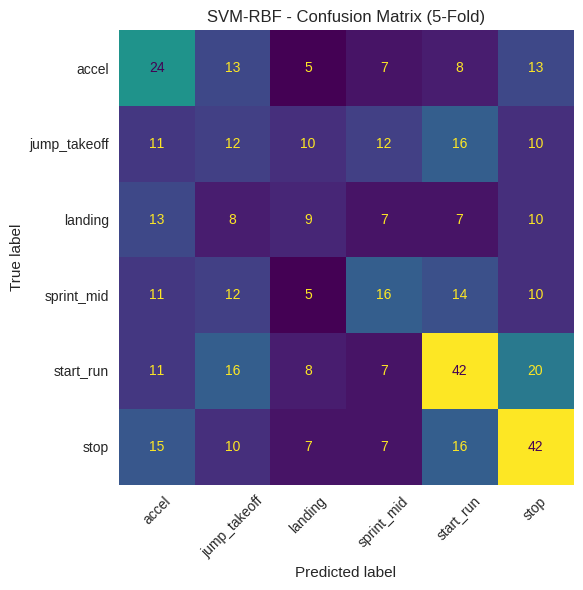

In [64]:
### Confusion Matrix 5-Fold

cm5Fold = confusion_matrix(y_train, yPred5Fold)

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(confusion_matrix=cm5Fold, display_labels=le.classes_).plot(ax=ax, xticks_rotation=45, colorbar=False)

ax.set_title(f"{bestTunedModel} - Confusion Matrix (5-Fold)")
plt.grid(False)
plt.tight_layout()
plt.savefig(S7 / "plots" / "confusion_matrix_5fold.png", dpi=150, bbox_inches="tight")
plt.show()

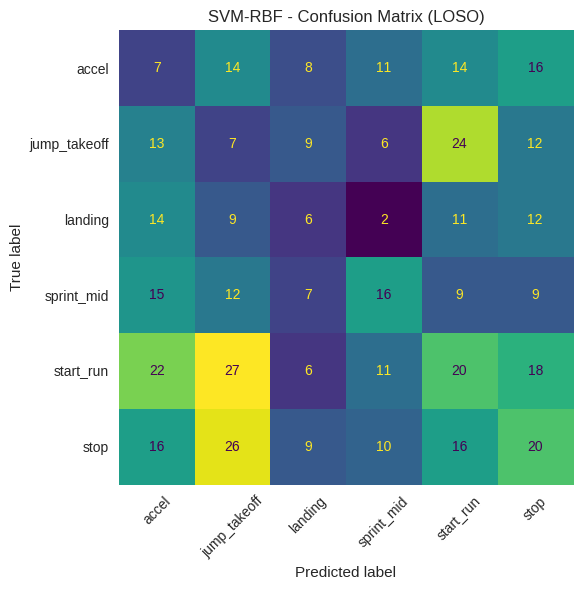

In [65]:
### Confusion Matrix LOSO

cmLOSO = confusion_matrix(y_train, yPredLOSO)

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(confusion_matrix=cmLOSO, display_labels=le.classes_).plot(ax=ax, xticks_rotation=45, colorbar=False)

ax.set_title(f"{bestTunedModel} - Confusion Matrix (LOSO)")
plt.grid(False)
plt.tight_layout()
plt.savefig(S7 / "plots" / "confusion_matrix_loso.png", dpi=150, bbox_inches="tight")
plt.show()

# Error Analysis
Error analysis is performed on only LOSO due to it reflecting errors on unseen athletes. 5-Fold cross validation could possible underestimate errors since training and testing data could overlap. So, to identify weaknesses I believe LOSO is better to analyze.


In [66]:
### Error Analysis
##Stores most common LOSO misclassifications
errorPairs = []

for i, actualLabel in enumerate(le.classes_): #Loop through both actual and predicted labels in confusion matrix.
  for j, predictedLabel in enumerate(le.classes_):
    if i != j and cmLOSO[i, j] > 0: #We want to ignore the diagonal predicts since those are the correct predictions
      errorPairs.append({
          "Actual": actualLabel,
          "Predicted": predictedLabel,
          "Count": int(cmLOSO[i, j])
      })

errorAnalysisDF = pd.DataFrame(errorPairs).sort_values("Count", ascending=False).reset_index(drop=True)
display(errorAnalysisDF.head(10))

errorAnalysisDF.to_csv(S7 / "tables" / "topMisclassificationsLOSO.csv", index=False)

,Actual,Predicted,Count
0,start_run,jump_takeoff,27
1,stop,jump_takeoff,26
2,jump_takeoff,start_run,24
3,start_run,accel,22
4,start_run,stop,18
5,accel,stop,16
6,stop,start_run,16
7,stop,accel,16
8,sprint_mid,accel,15
9,accel,start_run,14


# System Intregration
The purpose of system integration is to make a function that allows for usage of the full pipeline on a new raw dataset. We use the windowing and feature extraction and then use the best model to run on a raw dataset. True evaluation of the test set comes next.


In [67]:
###System integration function used for how the model would be used in practice
##Input is raw biosensor data, where it then creates the windows and features in which it outputs predictions.

def predictMotionFromRawDF(
    rawDF,
    trainedModel=bestEstimator,
    labelEncoder=le,
    samplingRate=FS,
    windowSeconds=WINDOW_SECONDS,
    stepRatio=STEP_RATIO,
    minSamples=1,
    ):

  inferenceDF = rawDF.copy()

  #Convert timestamps to datetime and create magnitudes if they are missing
  if "Timestamp" in inferenceDF.columns:
    inferenceDF["Timestamp"] = pd.to_datetime(inferenceDF["Timestamp"], errors="coerce")

  if "Acc_Mag" not in inferenceDF.columns and {"Acc_X", "Acc_Y", "Acc_Z"}.issubset(inferenceDF.columns):
    inferenceDF["Acc_Mag"] = np.sqrt(inferenceDF["Acc_X"]**2 + inferenceDF["Acc_Y"]**2 + inferenceDF["Acc_Z"]**2)

  if "Gyro_Mag" not in inferenceDF.columns and {"Gyro_X", "Gyro_Y", "Gyro_Z"}.issubset(inferenceDF.columns):
    inferenceDF["Gyro_Mag"] = np.sqrt(inferenceDF["Gyro_X"]**2 + inferenceDF["Gyro_Y"]**2 + inferenceDF["Gyro_Z"]**2)

  #This converts the raw data into windowed features
  featureInferenceDF = extract_window_features(
      inferenceDF,
      sampling_rate_hz=samplingRate,
      window_seconds=windowSeconds,
      step_ratio=stepRatio,
      min_samples=minSamples
  ).copy()

  if featureInferenceDF.empty: #Check if there were no valid windows, return empty DF if so
    return pd.DataFrame(columns=["Athlete_ID", "window_start", "window_end", "Predicted_Label"])

  inferX = featureInferenceDF.drop(columns=META_COLS + ["Event_Label"], errors="ignore").copy()
  inferX_sc = scaler.transform(inferX) #Scale using the same scaler fitted on training data
  yPredCodes = trainedModel.predict(inferX_sc)
  yPredLabels = labelEncoder.inverse_transform(yPredCodes)

  outputDF = featureInferenceDF[["Athlete_ID", "window_start", "window_end", "Event_Label"]].copy()
  outputDF = outputDF.rename(columns={"Event_Label": "Actual_Label"}) #***Added actual labels for confirmation but should be removed if using another raw dataset since won't always have correct labels to assume***
  outputDF["Predicted_Label"] = yPredLabels
  outputDF["Correct Label?"] = outputDF["Actual_Label"] == outputDF["Predicted_Label"]

  accuracyPercentage = outputDF["Correct Label?"].mean() * 100
  print(f"Accuracy: {accuracyPercentage:.2f}%")

  return outputDF

integrationPreviewDF = predictMotionFromRawDF(df_clean)
display(integrationPreviewDF.head())

integrationPreviewDF.to_csv(S7 / "tables" / "systemIntegrationPreview.csv", index=False)

Accuracy: 86.90%


,Athlete_ID,window_start,window_end,Actual_Label,Predicted_Label,Correct Label?
0,A001,2025-05-11 12:14:53.417747,2025-05-11 12:14:54.417747,sprint_mid,stop,False
1,A001,2025-05-11 12:14:53.667747,2025-05-11 12:14:54.667747,sprint_mid,landing,False
2,A001,2025-05-11 12:14:53.917747,2025-05-11 12:14:54.917747,landing,landing,True
3,A001,2025-05-11 12:14:54.167747,2025-05-11 12:14:55.167747,accel,accel,True
4,A001,2025-05-11 12:14:54.417747,2025-05-11 12:14:55.417747,accel,sprint_mid,False


# Final Test Set Evaluation
The held-out 20% test set is evaluated here — after all model selection, tuning, and CV analysis is complete. These are the unbiased final performance numbers.

### Test Set Evaluation

Each tuned model is evaluated on the held-out 20% test set. This is the final unbiased accuracy estimate — the test set was never used during training or tuning.

,Test Accuracy,Test F1-macro
Model,,
Random Forest,0.3621,0.3466
XGBoost,0.3621,0.3437
MLP,0.3621,0.3560
SVM-RBF,0.3448,0.3360
AdaBoost,0.2759,0.1298
Decision Tree,0.2155,0.2139
Naive Bayes,0.2155,0.2019


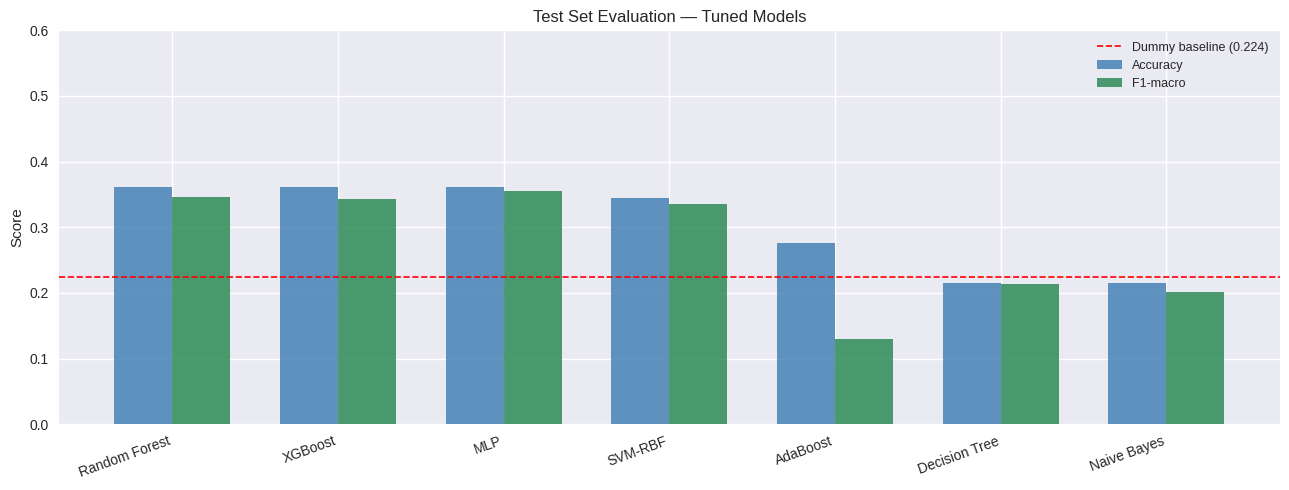

Classification report — Random Forest:
              precision    recall  f1-score   support

       accel       0.42      0.29      0.34        17
jump_takeoff       0.32      0.39      0.35        18
     landing       0.27      0.21      0.24        14
  sprint_mid       0.27      0.35      0.31        17
   start_run       0.46      0.50      0.48        26
        stop       0.38      0.33      0.36        24

    accuracy                           0.36       116
   macro avg       0.35      0.35      0.35       116
weighted avg       0.37      0.36      0.36       116



In [68]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

test_rows = []
for name, gs in tuned_models.items():
    y_pred = gs.best_estimator_.predict(X_test_sc)
    acc    = accuracy_score(y_test, y_pred)
    f1     = f1_score(y_test, y_pred, average="macro", zero_division=0)
    test_rows.append({
        "Model":           name,
        "Test Accuracy":   round(acc, 4),
        "Test F1-macro":   round(f1,  4),
    })

test_df = (
    pd.DataFrame(test_rows)
    .set_index("Model")
    .sort_values("Test Accuracy", ascending=False)
)

display(test_df)

# Bar chart — accuracy + F1
x = np.arange(len(test_df))
w = 0.35
fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - w/2, test_df["Test Accuracy"], w, label="Accuracy", color="steelblue", alpha=0.85)
ax.bar(x + w/2, test_df["Test F1-macro"], w, label="F1-macro",  color="seagreen",  alpha=0.85)
ax.axhline(DUMMY_BASELINE_SKF, color="red", linestyle="--", linewidth=1.2,
           label=f"Dummy baseline ({DUMMY_BASELINE_SKF:.3f})")
ax.set_xticks(x)
ax.set_xticklabels(test_df.index, rotation=20, ha="right")
ax.set_ylabel("Score")
ax.set_title("Test Set Evaluation — Tuned Models")
ax.set_ylim(0, 0.6)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(S6 / "plots" / "test_set_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close("all")

# Print classification report for the best model
best_name = test_df["Test Accuracy"].idxmax()
best_pred = tuned_models[best_name].best_estimator_.predict(X_test_sc)
print(f"Classification report — {best_name}:")
print(classification_report(y_test, best_pred, target_names=le.classes_, zero_division=0))


### Unified Model Comparison Table

For each tuned model: key hyperparameter settings, test-set accuracy, precision, recall, and F1-macro.

In [69]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def key_settings(name, gs):
    p = {k.replace("clf__", ""): v for k, v in gs.best_params_.items()}
    if name == "Random Forest":
        return f"n_est={p["n_estimators"]}, max_depth={p["max_depth"]}, min_leaf={p["min_samples_leaf"]}"
    elif name == "SVM-RBF":
        return f"C={p["C"]}, gamma={p["gamma"]}"
    elif name == "Hist Gradient Boosting":
        return f"lr={p["learning_rate"]}, max_iter={p["max_iter"]}, max_depth={p["max_depth"]}"
    elif name == "MLP":
        return f"layers={p["hidden_layer_sizes"]}, alpha={p["alpha"]}, lr={p["learning_rate_init"]}"
    elif name == "KNN":
        return f"k={p["n_neighbors"]}, weights={p["weights"]}, metric={p["metric"]}"
    elif name == "Decision Tree":
        return f"max_depth={p["max_depth"]}, min_leaf={p["min_samples_leaf"]}, criterion={p["criterion"]}"
    elif name == "Naive Bayes":
        return f"var_smoothing={p["var_smoothing"]:.0e}"
    elif name == "AdaBoost":
        return f"n_est={p["n_estimators"]}, lr={p["learning_rate"]}"
    elif name == "XGBoost":
        return f"n_est={p["n_estimators"]}, max_depth={p["max_depth"]}, lr={p["learning_rate"]}"
    return str(p)

unified_rows = []
for name, gs in tuned_models.items():
    y_pred = gs.best_estimator_.predict(X_test_sc)
    unified_rows.append({
        "Model":      name,
        "Key Settings": key_settings(name, gs),
        "Accuracy":   round(accuracy_score(y_test, y_pred), 4),
        "Precision":  round(precision_score(y_test, y_pred, average="macro", zero_division=0), 4),
        "Recall":     round(recall_score(y_test, y_pred,    average="macro", zero_division=0), 4),
        "F1-macro":   round(f1_score(y_test, y_pred,        average="macro", zero_division=0), 4),
    })

unified_df = (
    pd.DataFrame(unified_rows)
    .set_index("Model")
    .sort_values("F1-macro", ascending=False)
)

display(unified_df)


,Key Settings,Accuracy,Precision,Recall,F1-macro
Model,,,,,
MLP,"layers=(128, 64), alpha=0.0001, lr=0.01",0.3621,0.3580,0.3561,0.3560
Random Forest,"n_est=100, max_depth=10, min_leaf=4",0.3621,0.3543,0.3473,0.3466
XGBoost,"n_est=400, max_depth=5, lr=0.05",0.3621,0.3488,0.3457,0.3437
SVM-RBF,"C=10, gamma=scale",0.3448,0.3440,0.3376,0.3360
Decision Tree,"max_depth=15, min_leaf=8, criterion=gini",0.2155,0.2397,0.2355,0.2139
Naive Bayes,var_smoothing=1e-11,0.2155,0.2063,0.2044,0.2019
AdaBoost,"n_est=300, lr=0.01",0.2759,0.0940,0.2131,0.1298


### ANN vs Classical Models — Comparison

,Key Settings,Accuracy,Precision,Recall,F1-macro
Model,,,,,
MLP,"layers=(128, 64), alpha=0.0001, lr=0.01",0.3621,0.3580,0.3561,0.3560
Random Forest,"n_est=100, max_depth=10, min_leaf=4",0.3621,0.3543,0.3473,0.3466
XGBoost,"n_est=400, max_depth=5, lr=0.05",0.3621,0.3488,0.3457,0.3437
SVM-RBF,"C=10, gamma=scale",0.3448,0.3440,0.3376,0.3360
Decision Tree,"max_depth=15, min_leaf=8, criterion=gini",0.2155,0.2397,0.2355,0.2139
Naive Bayes,var_smoothing=1e-11,0.2155,0.2063,0.2044,0.2019
ANN,"layers=(128,64), dropout=0.3, lr=1e-3",0.2069,0.1688,0.1854,0.1655
AdaBoost,"n_est=300, lr=0.01",0.2759,0.0940,0.2131,0.1298


Saved ann_vs_classical.csv


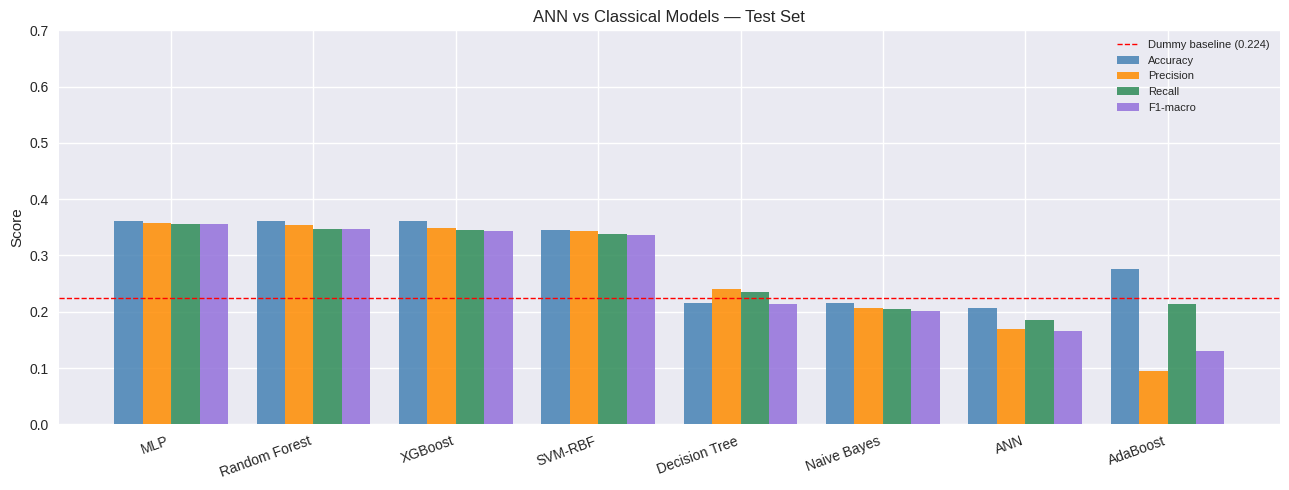

In [70]:
# Build comparison dataframe: classical + ANN
ann_row = pd.DataFrame([{
    "Key Settings": "layers=(128,64), dropout=0.3, lr=1e-3",
    "Accuracy":  round(ann_acc,  4),
    "Precision": round(ann_prec, 4),
    "Recall":    round(ann_rec,  4),
    "F1-macro":  round(ann_f1,   4),
}], index=pd.Index(["ANN"], name="Model"))

metric_cols = ["Accuracy", "Precision", "Recall", "F1-macro"]
compare_df  = pd.concat([unified_df[["Key Settings"] + metric_cols], ann_row])
compare_df  = compare_df.sort_values("F1-macro", ascending=False)

display(compare_df)
compare_df.to_csv(S6 / "tables" / "ann_vs_classical.csv")
print("Saved ann_vs_classical.csv")

# Bar chart
x = np.arange(len(compare_df))
w = 0.2
fig, ax = plt.subplots(figsize=(13, 5))
for i, (col, color) in enumerate(zip(
        metric_cols, ["steelblue", "darkorange", "seagreen", "mediumpurple"])):
    ax.bar(x + (i - 1.5) * w, compare_df[col], w, label=col, color=color, alpha=0.85)
ax.axhline(DUMMY_BASELINE_SKF, color="red", linestyle="--", linewidth=1,
           label=f"Dummy baseline ({DUMMY_BASELINE_SKF:.3f})")
ax.set_xticks(x)
ax.set_xticklabels(compare_df.index, rotation=20, ha="right")
ax.set_ylabel("Score")
ax.set_title("ANN vs Classical Models — Test Set")
ax.set_ylim(0, 0.7)
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(S6 / "plots" / "ann_vs_classical.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close("all")


### Confusion Matrices

Per-model confusion matrices on the held-out test set, saved to `S6/plots/`.

In [71]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

for name, gs in tuned_models.items():
    y_pred = gs.best_estimator_.predict(X_test_sc)
    cm = confusion_matrix(y_test, y_pred, labels=np.arange(len(le.classes_)))

    fig, ax = plt.subplots(figsize=(7, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(ax=ax, colorbar=True, cmap="Blues", xticks_rotation=30)
    ax.set_title(f"Confusion Matrix — {name}", fontsize=11)
    plt.tight_layout()

    fname = "cm_" + name.lower().replace(" ", "_").replace("-", "_") + ".png"
    plt.savefig(S6 / "plots" / fname, dpi=150, bbox_inches="tight")
    # plt.show()
    plt.close("all")
    print(f"Saved {fname}")


Saved cm_random_forest.png
Saved cm_svm_rbf.png
Saved cm_decision_tree.png
Saved cm_naive_bayes.png
Saved cm_adaboost.png
Saved cm_xgboost.png
Saved cm_mlp.png


### Classical Model Results — Final Comparison Table

All models side by side. Best value per metric is highlighted in green.

In [72]:
metric_cols = ["Accuracy", "Precision", "Recall", "F1-macro"]

classical_df = unified_df[["Key Settings"] + metric_cols].copy()
classical_df.to_csv(S6 / "tables" / "classical_model_results.csv")
print("Saved classical_model_results.csv\n")

display(classical_df)

print("\nBest per metric:")
for col in metric_cols:
    best_model = classical_df[col].idxmax()
    best_val   = classical_df[col].max()
    print(f"  {col:<12} → {best_model} ({best_val:.4f})")


Saved classical_model_results.csv



,Key Settings,Accuracy,Precision,Recall,F1-macro
Model,,,,,
MLP,"layers=(128, 64), alpha=0.0001, lr=0.01",0.3621,0.3580,0.3561,0.3560
Random Forest,"n_est=100, max_depth=10, min_leaf=4",0.3621,0.3543,0.3473,0.3466
XGBoost,"n_est=400, max_depth=5, lr=0.05",0.3621,0.3488,0.3457,0.3437
SVM-RBF,"C=10, gamma=scale",0.3448,0.3440,0.3376,0.3360
Decision Tree,"max_depth=15, min_leaf=8, criterion=gini",0.2155,0.2397,0.2355,0.2139
Naive Bayes,var_smoothing=1e-11,0.2155,0.2063,0.2044,0.2019
AdaBoost,"n_est=300, lr=0.01",0.2759,0.0940,0.2131,0.1298



Best per metric:
  Accuracy     → MLP (0.3621)
  Precision    → MLP (0.3580)
  Recall       → MLP (0.3561)
  F1-macro     → MLP (0.3560)
